# `RAG:` Assistente Técnico para Edifícios Verdes e Net Zero

---

**`DISCIPLINA:`** Processamento de Linguagem Natural, Chatbots & Virtual Agents  

**`INSTITUIÇÃO:`** FIAP · (Faculdade de Informática e Administração Paulista)

**`ANO:`** 2026

**`TURMA:`** 2TIAPY

**`CURSO:`** Inteligência Artificial

**`EQUIPE:`**
*  Arthur Baptista dos Santos - 565346
*  João Pedro de Moura Dutra Franco - 561738
*  Nelson Félix Neto - 565603

---

## `Arquitetura do Sistema`

```
Corpus (15 docs técnicos: TXT/PDF/DOCX/HTML)
         ↓  [Extração + Limpeza]
    Texto Normalizado
         ↓  [Chunking Semântico — 512-1024 tokens, overlap 2 sentenças]
    Chunks Estruturados + Metadados
         ↓  [intfloat/multilingual-e5-base — "passage:" prefix]
    Vetores 768D
         ↓  [ChromaDB Persistente — similaridade coseno]
    Banco Vetorial com Metadados (fonte, categoria, subcategoria, ano)
         ↓  [Busca top-k — "query:" prefix]
    Top-5 Chunks Relevantes
         ↓  [Qwen2.5:3B via Ollama — System Prompt Restritivo]
    Resposta com Citações Obrigatórias
```

---

## `Stack Tecnológica:` `Decisões e Justificativas`

| `Componente` | `Tecnologia` | `Justificativa` |
|---|---|---|
| **Embedding** | `intfloat/multilingual-e5-base` | SOTA multilingual, excelente para PT técnico, busca assimétrica com prefixos |
| **Banco Vetorial** | ChromaDB Persistente | Persistência nativa, filtros por metadado, API simples, open-source |
| **LLM Local** | Qwen2.5:3B via Ollama | Multilingual, aceito pela rubrica, ~2GB RAM, sem GPU obrigatória |
| **Chunker** | Custom NLTK Semântico | Preserva seções normativas, artigos e créditos de certificação |
| **Framework** | Custom Pipeline (sem LangChain) | Controle total, sem overhead, mais transparente para avaliação |

## `Corpus:` `15 Documentos` · `3 Categorias` · `8 Temas`

| `Categoria` | `Documentos` |
|---|---|
| Certificação/Norma (5) | PROCEL EDIFICA, AQUA-HQE, LEED v4 Água, LEED v4 Energia, NBR 15575 |
| Relatório Técnico (5) | Net Zero Energia, Net Zero Água, IEA Buildings 2023, CBCS, ISO 50001 |
| Manual/Tecnologia (5) | Energia Solar FV, Reuso Águas, NBR 5626, EDGE/GBC, BEMS |

## `Etapa 1:` `Instalações Críticas do Sistema`

In [ ]:
import subprocess
from rich.console import Console

console = Console()

def _run(cmd, desc):
    console.print(f"[bold cyan] ⧖ {desc}...[/bold cyan]")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if r.returncode != 0:
        console.print(f"[bold red] ✕ ERRO CRÍTICO EM: {desc}[/bold red]\n{r.stderr[:200]}")
    else:
        console.print(f"[bold green] ✓ {desc} CONCLUÍDO.[/bold green]")
    return r

# Infraestrutura Linux
_run("apt-get update && apt-get install -y zstd", "Instalando dependências Linux")
_run("curl -fsSL https://ollama.com/install.sh | sh", "Instalando Ollama")

# Bibliotecas Python (Lista completa para não faltar nada)
_run("pip install -q chromadb sentence-transformers pymupdf python-docx beautifulsoup4 scikit-learn matplotlib seaborn tqdm nltk numpy pandas requests rich", "Instalando dependências Python")

 ⧖ Instalando dependências Linux...

 ✓ Instalando dependências Linux CONCLUÍDO.

 ⧖ Instalando Ollama...

 ✓ Instalando Ollama CONCLUÍDO.

 ⧖ Instalando dependências Python...

 ✓ Instalando dependências Python CONCLUÍDO.

CompletedProcess(args='pip install -q chromadb sentence-transformers pymupdf python-docx beautifulsoup4 scikit-learn matplotlib seaborn tqdm nltk numpy pandas requests rich', returncode=0, stdout='     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.0 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 93.5 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 90.3 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 25.9 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.8 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 136.7 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 92.9 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 7.9 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 19.9 MB/s eta 0:00:00\n   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 7.3 MB/s eta 0:00:00\

## `Etapa 2:` `Imports e Configuração Global`
Consolidação de todas as bibliotecas necessárias para evitar erros de escopo durante a execução do pipeline.

In [ ]:
import os, re, json, time, warnings, requests, subprocess, urllib.request
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from collections import defaultdict, Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer

import fitz
from docx import Document as DocxDoc
from bs4 import BeautifulSoup
from pathlib import Path

import chromadb

from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich import box
from tqdm import tqdm

console = Console()

CONFIG = {
    "CORPUS_DIR"    : "./corpus",
    "CHROMA_DIR"    : "./chroma_db",
    "EMBED_MODEL"   : "intfloat/multilingual-e5-base",
    "OLLAMA_URL"    : "http://localhost:11434/api/generate",
    "LLM_MODEL"     : "qwen2.5:3b",
    "LLM_TEMP"      : 0.1,
    "LLM_MAX_TOKENS": 600,
    "COLLECTION"    : "green_buildings",
    "CHUNK_MAX_TOK" : 800,
    "CHUNK_OVERLAP" : 2,
    "TOP_K"         : 5,
}

Path(CONFIG["CORPUS_DIR"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["CHROMA_DIR"]).mkdir(parents=True, exist_ok=True)

console.print(Panel(
    f"[bold cyan]Configurações Carregadas:[/bold cyan]\n"
    f"⚙⚙ [bold]Modelo Embedding:[/bold] {CONFIG['EMBED_MODEL']}\n"
    f"⌨ [bold]LLM Local:[/bold] {CONFIG['LLM_MODEL']} via Ollama\n"
    f"⌸ [bold]Banco Vetorial:[/bold] ChromaDB em {CONFIG['CHROMA_DIR']}",
    title="[bold green] ✔ Setup Concluído", border_style="green"
))

╭──────────────────────────────────────────────  ✔ Setup Concluído ───────────────────────────────────────────────╮
│ Configurações Carregadas:                                                                                       │
│ ⚙⚙ Modelo Embedding: intfloat/multilingual-e5-base                                                              │
│ ⌨ LLM Local: qwen2.5:3b via Ollama                                                                              │
│ ⌸ Banco Vetorial: ChromaDB em ./chroma_db                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## `Etapa 3:` `Inicialização do Servidor LLM Local`
Subida do processo do Ollama em background e download do modelo Qwen escolhido para a geração das respostas do RAG.

In [ ]:
console.rule("[bold yellow]Iniciando Servidor Ollama e Baixando Modelo")

process = subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)

try:
    response = urllib.request.urlopen('http://localhost:11434/')
    if response.getcode() == 200:
        console.print("✔ [bold green]Servidor Ollama respondendo na porta 11434[/bold green]")

        with console.status(f"[bold cyan]Baixando modelo {CONFIG['LLM_MODEL']} (Isso levará um tempo)...", spinner="dots"):
            pull_process = subprocess.run(["ollama", "pull", CONFIG['LLM_MODEL']], capture_output=True, text=True)

        if pull_process.returncode == 0:
            console.print(f"↗ [bold green]Modelo {CONFIG['LLM_MODEL']} pronto para uso![/bold green]")
        else:
            console.print(f"✖ [bold red]Erro no pull do modelo:\n{pull_process.stderr}[/bold red]")
except Exception as e:
    console.print(f"✖ [bold red]Erro crítico ao conectar com o Ollama: {e}[/bold red]")

─────────────────────────────────── Iniciando Servidor Ollama e Baixando Modelo ───────────────────────────────────

✔ Servidor Ollama respondendo na porta 11434

Output()

↗ Modelo qwen2.5:3b pronto para uso!

## `Etapa 4:` `Definição e Criação do Corpus`
Armazenamento local em disco dos documentos (fictícios/normativos) que irão compor a base de conhecimento (Knowledge Base) do assistente.

In [ ]:
console.rule("[bold blue]Definição do Corpus Técnico")

CORPUS_METADATA = [
    # ── CATEGORIA 1: NORMAS E GUIAS DE CERTIFICAÇÃO ──────────────────────────
    {
        "id": "doc01", "arquivo": "doc01_procel_edifica.txt",
        "titulo": "PROCEL EDIFICA — Eficiência Energética nas Edificações",
        "fonte": "PROCEL/Eletrobrás", "categoria": "Certificação/Norma",
        "subcategoria": "energia", "ano": 2023, "vigencia": "vigente",
    },
    {
        "id": "doc02", "arquivo": "doc02_aqua_hqe.txt",
        "titulo": "Referencial Técnico AQUA-HQE — Edificações em Operação",
        "fonte": "Fundação Vanzolini / Cerway", "categoria": "Certificação/Norma",
        "subcategoria": "energia/água", "ano": 2020, "vigencia": "vigente",
    },
    {
        "id": "doc03", "arquivo": "doc03_leed_v4_agua.txt",
        "titulo": "LEED v4 BD+C — Water Efficiency (Eficiência Hídrica)",
        "fonte": "USGBC / GBC Brasil", "categoria": "Certificação/Norma",
        "subcategoria": "água", "ano": 2021, "vigencia": "vigente",
    },
    {
        "id": "doc04", "arquivo": "doc04_leed_v4_energia.txt",
        "titulo": "LEED v4 BD+C — Energy and Atmosphere (Energia e Atmosfera)",
        "fonte": "USGBC / GBC Brasil", "categoria": "Certificação/Norma",
        "subcategoria": "energia", "ano": 2021, "vigencia": "vigente",
    },
    {
        "id": "doc05", "arquivo": "doc05_nbr_15575.txt",
        "titulo": "ABNT NBR 15575:2021 — Edificações Habitacionais — Desempenho",
        "fonte": "ABNT", "categoria": "Certificação/Norma",
        "subcategoria": "energia", "ano": 2021, "vigencia": "vigente",
    },
    # ── CATEGORIA 2: RELATÓRIOS TÉCNICOS E CIENTÍFICOS ───────────────────────
    {
        "id": "doc06", "arquivo": "doc06_net_zero_energia.txt",
        "titulo": "Net Zero Energy Buildings — Conceitos, Definições e Métricas",
        "fonte": "IEA / CBIC", "categoria": "Relatório Técnico",
        "subcategoria": "energia", "ano": 2022, "vigencia": "vigente",
    },
    {
        "id": "doc07", "arquivo": "doc07_net_zero_agua.txt",
        "titulo": "Net Zero Water Buildings — Autossuficiência Hídrica em Edificações",
        "fonte": "ILFI / ANA", "categoria": "Relatório Técnico",
        "subcategoria": "água", "ano": 2022, "vigencia": "vigente",
    },
    {
        "id": "doc08", "arquivo": "doc08_iea_buildings.txt",
        "titulo": "IEA Buildings — Tracking Buildings 2023",
        "fonte": "IEA (International Energy Agency)", "categoria": "Relatório Técnico",
        "subcategoria": "energia", "ano": 2023, "vigencia": "vigente",
    },
    {
        "id": "doc09", "arquivo": "doc09_cbcs_sustentabilidade.txt",
        "titulo": "CBCS — Guia de Boas Práticas em Sustentabilidade na Construção Civil",
        "fonte": "CBCS (Conselho Brasileiro de Construção Sustentável)", "categoria": "Relatório Técnico",
        "subcategoria": "energia/água", "ano": 2019, "vigencia": "vigente",
    },
    {
        "id": "doc10", "arquivo": "doc10_iso_50001.txt",
        "titulo": "ISO 50001:2018 — Sistemas de Gestão de Energia",
        "fonte": "ISO / ABNT NBR ISO 50001", "categoria": "Relatório Técnico",
        "subcategoria": "energia", "ano": 2018, "vigencia": "vigente",
    },
    # ── CATEGORIA 3: MANUAIS E ESPECIFICAÇÕES DE TECNOLOGIAS ─────────────────
    {
        "id": "doc11", "arquivo": "doc11_energia_solar_fv.txt",
        "titulo": "Manual de Dimensionamento de Sistemas Fotovoltaicos",
        "fonte": "INMETRO / ABSOLAR", "categoria": "Manual/Tecnologia",
        "subcategoria": "energia", "ano": 2023, "vigencia": "vigente",
    },
    {
        "id": "doc12", "arquivo": "doc12_reuso_aguas.txt",
        "titulo": "Sistemas de Reuso de Águas Cinzas e Aproveitamento Pluvial",
        "fonte": "ANA / CBIC", "categoria": "Manual/Tecnologia",
        "subcategoria": "água", "ano": 2021, "vigencia": "vigente",
    },
    {
        "id": "doc13", "arquivo": "doc13_nbr_5626.txt",
        "titulo": "ABNT NBR 5626:2020 — Sistemas Prediais de Distribuição de Água Fria e Quente",
        "fonte": "ABNT", "categoria": "Manual/Tecnologia",
        "subcategoria": "água", "ano": 2020, "vigencia": "vigente",
    },
    {
        "id": "doc14", "arquivo": "doc14_edge_gbc.txt",
        "titulo": "EDGE — Excellence in Design for Greater Efficiencies (GBC Brasil)",
        "fonte": "IFC / GBC Brasil", "categoria": "Manual/Tecnologia",
        "subcategoria": "energia/água", "ano": 2022, "vigencia": "vigente",
    },
    {
        "id": "doc15", "arquivo": "doc15_bems.txt",
        "titulo": "BEMS — Building Energy Management Systems: Especificações e Integração",
        "fonte": "ASHRAE / ABRAVA", "categoria": "Manual/Tecnologia",
        "subcategoria": "energia", "ano": 2023, "vigencia": "vigente",
    },
]

CORPUS_TEXTS = {

"doc01_procel_edifica.txt": """PROCEL EDIFICA — PROGRAMA NACIONAL DE EFICIÊNCIA ENERGÉTICA EM EDIFICAÇÕES
Eletrobrás / Ministério de Minas e Energia, 2023

1. HISTÓRICO E OBJETIVOS
O PROCEL EDIFICA foi criado em 2003 pela Eletrobrás em parceria com o Ministério de Minas e Energia com o objetivo de estimular o uso racional de energia elétrica em edificações comerciais, residenciais e públicas. O programa atua em quatro frentes: regulamentação técnica, etiquetagem, pesquisa e disseminação de boas práticas.

2. ETIQUETA NACIONAL DE CONSERVAÇÃO DE ENERGIA (ENCE)
A ENCE classifica edificações de A (mais eficiente) a E (menos eficiente). A avaliação considera:
- Envoltória: transmitância térmica, absortância solar e ventilação natural
- Iluminação artificial: Densidade de Potência de Iluminação (DPI)
- Condicionamento de ar: Coeficiente de Eficiência Energética (EER ou COP)
- Sistema de aquecimento de água: quando presente

Obrigatoriedade: edificações públicas federais novas ou reformadas acima de 500 m² desde 2014; edificações comerciais privadas acima de 500 m² desde 2021. O RTQ-R (residencial) opera em caráter voluntário com obrigatoriedade progressiva prevista.

3. REQUISITOS QUANTITATIVOS POR NÍVEL
Densidade de Potência de Iluminação (DPI) máxima para nível A:
- Escritórios de atividade geral: 6,0 W/m²
- Salas de reunião: 8,0 W/m²
- Corredores e halls: 3,0 W/m²
- Depósitos e almoxarifados: 3,0 W/m²

Eficiência do sistema de ar-condicionado:
- Splits e multi-splits: EER mínimo de 3,5 (nível A)
- Chillers de expansão direta (VRF): EER mínimo de 3,8
- Chillers de expansão indireta: COP mínimo de 5,0 (nível A)

4. CONSUMO DE REFERÊNCIA
Consumo médio de edificações brasileiras por tipologia:
- Edifícios de escritório: 120-220 kWh/m²/ano (média nacional)
- Hotéis: 180-400 kWh/UH/mês dependendo da categoria
- Hospitais: 250-550 kWh/leito/mês
- Shopping centers: 300-700 kWh/m²/ano (área locável)
Meta ENCE A para escritórios: ≤ 75 kWh/m²/ano com sistemas de controle automático.

5. ESTRATÉGIAS DE EFICIÊNCIA ENERGÉTICA
5.1 Envoltória passiva (sem consumo de energia):
- Orientação solar: fachada principal voltada para Norte (menor ganho de calor direto)
- Proteção solar: brises horizontais para face Norte e Sul; brises verticais para Leste e Oeste
- Materiais de cobertura com Índice de Refletância Solar (IRS) ≥ 29%
- Vidros com fator solar ≤ 0,40 em climas quentes (zonas 7 e 8)
- Isolamento térmico de cobertura: resistência mínima R = 1,0 m².K/W (nível A)
- Pé-direito mínimo de 2,60 m para facilitar ventilação natural

5.2 Sistemas ativos:
- Iluminação LED com sensores de presença (desligamento automático após 15 min sem ocupação)
- Sensores de luz natural com dimmerização automática
- Ar-condicionado com inversores de frequência (VRF) para ajuste de carga parcial
- Bombas e ventiladores com acionamento por inversor de frequência
- Sistema de gestão predial (BMS) com medição e monitoramento em tempo real
- Aquecimento solar de água com cobertura mínima de 70% da demanda anual

6. METAS DE REDUÇÃO DO CONSUMO NACIONAL
O Plano Nacional de Energia 2036 estabelece como meta a redução de 10% no consumo de energia elétrica nas edificações até 2032, equivalente a aproximadamente 15 TWh/ano. O cumprimento requer etiquetagem de 80% das novas construções acima de 500 m² e retrofit de 20% do estoque existente até 2030.
""",

"doc02_aqua_hqe.txt": """REFERENCIAL TÉCNICO DE CERTIFICAÇÃO AQUA-HQE™
Edificações em Operação — Versão Brasileira
Fundação Vanzolini / Cerway, 2020

1. APRESENTAÇÃO
O sistema AQUA-HQE (Alta Qualidade Ambiental) é gerenciado no Brasil pela Fundação Vanzolini em parceria com o organismo francês Cerway. Desenvolvido originalmente pelo CSTB (Centre Scientifique et Technique du Bâtiment) e adaptado ao contexto climático, normativo e cultural brasileiro a partir de 2008. O sistema abrange edificações residenciais, comerciais, industriais, de saúde e de ensino.

2. ESTRUTURA: 14 CATEGORIAS DE QUALIDADE AMBIENTAL
Preocupação 1 — ECOCONSTRUÇÃO:
- Categoria 1: Relação do edifício com seu entorno imediato (biodiversidade, microclima, vizinhança)
- Categoria 2: Escolha integrada de produtos, sistemas e processos construtivos
- Categoria 3: Canteiro de obras com baixo impacto ambiental

Preocupação 2 — ECOGESTÃO:
- Categoria 4: Gestão de energia (baseline PROCEL + metas de redução percentual)
- Categoria 5: Gestão de água (consumo potável, reuso, monitoramento)
- Categoria 6: Gestão dos resíduos de uso e operação
- Categoria 7: Manutenção e permanência do desempenho ambiental

Preocupação 3 — CONFORTO:
- Categoria 8: Conforto higrotérmico (temperatura operativa, umidade relativa)
- Categoria 9: Conforto acústico (NPS interno, isolamento de fachada)
- Categoria 10: Conforto visual (iluminância natural e artificial, ofuscamento)
- Categoria 11: Conforto olfativo (controle de COV, ventilação adequada)

Preocupação 4 — SAÚDE:
- Categoria 12: Qualidade sanitária dos ambientes
- Categoria 13: Qualidade sanitária do ar (renovação mínima ABNT NBR 16401)
- Categoria 14: Qualidade sanitária da água (NBR 5626, legionela, cloração)

3. NÍVEIS DE DESEMPENHO E REQUISITOS PARA CERTIFICAÇÃO
Cada categoria recebe um nível: Base, Bom, Superior ou Excelente.

Requisitos mínimos para certificação AQUA-HQE Bom:
- Nenhuma categoria em nível inferior ao Bom
- Mínimo de 7 categorias em Superior ou Excelente
- Mínimo de 3 categorias em Excelente

Requisitos para certificação AQUA-HQE Superior:
- 10 ou mais categorias em Superior ou Excelente
- Mínimo de 5 categorias em Excelente

Requisitos para certificação AQUA-HQE Excelente:
- 12 ou mais categorias em Excelente

4. GESTÃO DE ÁGUA — CATEGORIA 5 (REQUISITOS DETALHADOS)
Nível Bom:
- Instalação de dispositivos economizadores em todos os pontos de uso
- Redução mínima de 15% no consumo de água potável vs baseline normativo NBR 5626

Nível Superior:
- Redução mínima de 30% no consumo de água potável
- Aproveitamento de água pluvial para fins não potáveis (descarga, irrigação)
- Sistema de medição individualizada por uso (sanitários, irrigação, cozinha)
- Turbidez da água pluvial tratada: ≤ 2,0 UNT; pH: 6,0-9,0

Nível Excelente:
- Redução mínima de 50% no consumo de água potável
- Sistema de reuso de águas cinzas com tratamento secundário comprovado
- Monitoramento em tempo real com alertas automáticos de consumo anormal

5. GESTÃO DE ENERGIA — CATEGORIA 4
Nível Superior: redução de 25% no consumo de energia vs baseline PROCEL
Nível Excelente: redução de 40% no consumo + integração de geração on-site (FV)
A simulação termoenergética é obrigatória a partir do nível Superior (softwares aceitos: EnergyPlus, DesignBuilder, IDA ICE ou equivalente validado pelo INMETRO).
""",

"doc03_leed_v4_agua.txt": """LEED v4 BD+C — WATER EFFICIENCY (WE)
Eficiência Hídrica em Edificações Novas e Grandes Reformas
USGBC / GBC Brasil, 2021

1. APRESENTAÇÃO
O sistema LEED v4 (Leadership in Energy and Environmental Design), mantido pelo USGBC (U.S. Green Building Council) e administrado no Brasil pelo GBC Brasil, é o sistema de certificação ambiental mais utilizado mundialmente, com mais de 100.000 projetos certificados em 180 países. A categoria Water Efficiency (WE) avalia o desempenho hídrico da edificação.

2. BASELINE DE REFERÊNCIA
O cálculo de eficiência hídrica no LEED v4 utiliza como baseline os valores de consumo por fixture conforme o Energy Policy Act 1992 e o Uniform Plumbing Code:
- Vaso sanitário (flush): 6,0 Lpf (litros por flush) — baseline
- Mictório: 1,9 Lpf — baseline
- Lavatório privado: 8,3 L/min — baseline
- Chuveiro: 9,5 L/min — baseline
- Torneira de cozinha: 8,3 L/min — baseline

3. PRÉ-REQUISITO WE: REDUÇÃO DE CONSUMO DE ÁGUA POTÁVEL (Obrigatório)
Para obter qualquer nível de certificação LEED, a edificação deve reduzir em no mínimo 20% o consumo de água potável nos fixtures internos em relação ao baseline calculado para ocupação e tipologia. Não há pontos atribuídos; é requisito eliminatório.

4. CRÉDITO WE CREDIT 1 — REDUÇÃO DO CONSUMO INTERNO (1-6 pontos)
Pontuação proporcional à redução adicional além do pré-requisito de 20%:
- 25% de redução: 1 ponto
- 30% de redução: 2 pontos
- 35% de redução: 3 pontos
- 40% de redução: 4 pontos
- 45% de redução: 5 pontos
- 50% de redução: 6 pontos (pontuação máxima)

Estratégias aceitas: fixtures de baixo fluxo, vasos com duplo acionamento (3/6 L), mictórios sem água, sensores de presença, medidores individuais.

5. CRÉDITO WE CREDIT 2 — USO EXTERNO DE ÁGUA (1-2 pontos)
Água para irrigação de jardins e áreas verdes:
- Redução de 50% vs baseline de irrigação calculado: 1 ponto
- Não usar água potável para irrigação (100% reuso ou chuva): 2 pontos
Baseline de irrigação calculado com base em evapotranspiração local (ET0) e espécies vegetais selecionadas.

6. CRÉDITO WE CREDIT 3 — MEDIÇÃO DO USO DE ÁGUA (1 ponto)
Instalação de medidores individuais por sistema (irrigação, processo, sanitários, torre de resfriamento). Os dados devem ser coletados e acompanhados para detectar vazamentos e consumo anormal.

7. CRÉDITO WE CREDIT 4 — GESTÃO DE ÁGUA EM TORRES DE RESFRIAMENTO (1-2 pontos)
Para edificações com sistema de ar-condicionado central a água:
- Monitoramento de condutividade e controle de purgas: 1 ponto
- Uso de água de reuso ou pluvial no make-up: 2 pontos

8. PONTUAÇÃO TOTAL E NÍVEIS DE CERTIFICAÇÃO
A categoria Water Efficiency vale até 11 pontos no LEED v4 BD+C.
Certificação LEED: Certified (40-49 pts), Silver (50-59 pts), Gold (60-79 pts), Platinum (80+ pts).
Projetos que visam LEED Gold ou Platinum devem atingir pelo menos 8-10 pontos em WE.
""",

"doc04_leed_v4_energia.txt": """LEED v4 BD+C — ENERGY AND ATMOSPHERE (EA)
Energia e Atmosfera em Edificações Novas
USGBC / GBC Brasil, 2021

1. ESTRUTURA DA CATEGORIA EA
A categoria Energy and Atmosphere (EA) é a de maior peso no LEED v4 BD+C, valendo até 33 pontos (de 110 possíveis). Divide-se em pré-requisitos obrigatórios e créditos opcionais.

2. PRÉ-REQUISITOS EA (Obrigatórios — sem pontuação)
EA Pré-requisito 1 — Commissioning Fundamental: verificação e documentação de que todos os sistemas de energia foram instalados e calibrados conforme projeto.
EA Pré-requisito 2 — Desempenho Energético Mínimo: a edificação deve superar em pelo menos 5% o custo de energia de uma edificação de referência modelada conforme ASHRAE Standard 90.1-2010 (para novas construções) ou 3% para grandes reformas. No Brasil, o benchmark equivalente é o RTQ-C (INMETRO/PROCEL).
EA Pré-requisito 3 — Medição de Energia em Nível de Edificação: instalação de medidor de energia na entrada geral.

3. CRÉDITO EA CREDIT 2 — OTIMIZAÇÃO DO DESEMPENHO ENERGÉTICO (1-18 pontos)
É o crédito de maior pontuação individual em todo o sistema LEED.
Pontuação baseada na redução do custo de energia vs edificação de referência:
- 6% de redução: 1 ponto | 8%: 2 pts | 10%: 3 pts | 12%: 4 pts
- 14%: 5 pts | 16%: 6 pts | 18%: 7 pts | 20%: 8 pts | 22%: 9 pts
- 24%: 10 pts | 26%: 11 pts | 28%: 12 pts | 30%: 13 pts | 34%: 14 pts
- 38%: 15 pts | 42%: 16 pts | 46%: 17 pts | 50%: 18 pts (máximo)
Metodologia: simulação energética whole-building (EnergyPlus ou IDA ICE) com modelagem de todos os sistemas.

4. CRÉDITO EA CREDIT 5 — GERAÇÃO DE ENERGIA RENOVÁVEL ON-SITE (1-3 pontos)
- 1% da demanda de energia por fontes renováveis: 1 ponto
- 5%: 2 pontos
- 10%: 3 pontos
Fontes aceitas: fotovoltaico, solar térmico (para energia total), eólico, biomassa, geotermia.

5. CRÉDITO EA CREDIT 6 — ENERGIA VERDE E CRÉDITOS DE CARBONO (1-2 pontos)
Aquisição de energia renovável certificada (tarifa verde) ou Créditos de Carbono Verificados (VCCs) para 50% ou 100% da demanda energética.

6. REQUISITOS PARA DIFERENTES NÍVEIS
Para LEED Platinum (80+ pontos): necessidade de atingir 15-18 pontos em EA, exigindo redução energética de 42-50% e geração on-site significativa.
Para LEED Gold (60-79 pontos): 10-13 pontos em EA (redução de 24-30%) com comissioning avançado.

7. DESEMPENHO TÉRMICO DA ENVOLTÓRIA (Requisito para simulação)
Transmitância máxima da cobertura:
- Climas quentes (zonas ASHRAE 1-3, equivalente a ZB 7-8 Brasil): U ≤ 0,273 W/m²K
- Climas temperados (zonas ASHRAE 4-5, equivalente a ZB 1-3 Brasil): U ≤ 0,220 W/m²K
Fator solar máximo para vidros:
- Climas quentes: SHGC ≤ 0,25 (equivalente a Fator Solar ≤ 0,25)
- Climas temperados: sem restrição de SHGC (maximizar ganhos solares de inverno)
""",

"doc05_nbr_15575.txt": """ABNT NBR 15575:2021 — EDIFICAÇÕES HABITACIONAIS — DESEMPENHO
Associação Brasileira de Normas Técnicas (ABNT), 2021

1. ESCOPO E ESTRUTURA
A ABNT NBR 15575:2021 estabelece requisitos e critérios de desempenho mínimos para edificações habitacionais. É composta de 6 partes:
- Parte 1: Requisitos gerais
- Parte 2: Sistemas estruturais
- Parte 3: Sistemas de pisos
- Parte 4: Sistemas de vedações verticais internas e externas
- Parte 5: Sistemas de coberturas
- Parte 6: Sistemas hidrossanitários

2. NÍVEIS DE DESEMPENHO
A norma define três níveis de desempenho:
- Nível M (Mínimo): atendimento obrigatório para aprovação de projetos no Brasil
- Nível I (Intermediário): desempenho acima do mínimo, recomendado para a maioria das edificações
- Nível S (Superior): máximo desempenho previsto pela norma, altamente recomendável

3. DESEMPENHO TÉRMICO — PARTE 1 (SUBSEÇÃO 11)
A avaliação de desempenho térmico é realizada para as 8 zonas bioclimáticas brasileiras conforme ABNT NBR 15220.

Zona Bioclimática 1 (Sul do Brasil — clima frio):
- Temperatura operativa mínima em dia típico de inverno: ≥ 17°C (nível M)
- Temperatura operativa mínima: ≥ 18°C (nível S)

Zona Bioclimática 8 (Norte e Nordeste — clima quente e úmido):
- Temperatura operativa máxima em dia típico de verão: ≤ ΔT máx. definido na tabela normativa
- Nível M: diferença máxima de 2°C acima da temperatura externa máxima diária
- Nível S: temperatura interior não pode superar a temperatura exterior máxima diária

4. TRANSMITÂNCIA TÉRMICA DA COBERTURA (TABELA 12 — PARTE 5)
Zona Bioclimática 1 e 2: U ≤ 2,30 W/(m²·K) para nível M; U ≤ 1,00 para nível S
Zona Bioclimática 3 e 4: U ≤ 2,30 W/(m²·K) para nível M; U ≤ 1,50 para nível S
Zona Bioclimática 5, 6, 7: U ≤ 2,30 W/(m²·K) para nível M; U ≤ 1,00 para nível S
Zona Bioclimática 8: U ≤ 2,30 W/(m²·K) para nível M; U ≤ 1,00 para nível S com absortância α ≤ 0,4 obrigatória

5. DESEMPENHO LUMÍNICO (SUBSEÇÃO 12)
Fator de luz diurna mínimo (FLD):
- Salas de estar: FLD ≥ 0,5% (nível M) e ≥ 1,5% (nível S)
- Dormitórios: FLD ≥ 0,5% (nível M) e ≥ 1,0% (nível S)
- Cozinhas: FLD ≥ 0,5% (nível M) e ≥ 1,5% (nível S)
- Área mínima de janela: pelo menos 1/8 da área do piso (Art. 12.1)

6. VIDA ÚTIL DE PROJETO (VUP)
- Estrutura: VUP ≥ 50 anos
- Cobertura (impermeabilização): VUP ≥ 20 anos
- Vedações externas: VUP ≥ 40 anos
- Instalações hidrossanitárias: VUP ≥ 20 anos
- Revestimentos de piso: VUP ≥ 13 anos
""",

"doc06_net_zero_energia.txt": """NET ZERO ENERGY BUILDINGS (NZEB) — CONCEITOS, DEFINIÇÕES E IMPLEMENTAÇÃO
Relatório Técnico CBIC / IEA, 2022

1. DEFINIÇÃO FUNDAMENTAL
Um Edifício Net Zero Energia (NZEB — Net Zero Energy Building) é uma edificação de alta eficiência energética que, em um período de análise de um ano, produz quantidade de energia renovável equivalente ou superior ao total consumido, quando medido no mesmo limite de sistema.

2. HIERARQUIA DE DEFINIÇÕES (IEA)
O IEA (International Energy Agency) identifica quatro hierarquias de Net Zero, em ordem crescente de abrangência:
- Net Zero Site Energy: balanço zero no local (energia produzida = energia consumida no ponto de uso)
- Net Zero Source Energy: balanço zero considerando perdas na geração e transmissão da rede elétrica
- Net Zero Cost Energy: balanço zero no custo (créditos de energia exportada = custo da energia importada)
- Net Zero Carbon Energy: balanço zero de carbono considerando o fator de emissão da rede elétrica

A definição mais utilizada em certificações é a Net Zero Site Energy.

3. HIERARQUIA DE PROJETO PARA NZEB (PASSIVE FIRST)
O IEA recomenda a seguinte hierarquia obrigatória de estratégias:
Nível 1 — Reduzir cargas térmicas (envoltória passiva): isolamento, sombreamento, orientação solar, massa térmica, ventilação natural.
Nível 2 — Eficientizar sistemas ativos: ar-condicionado de alta eficiência (COP ≥ 4,0), iluminação LED, bombas e ventiladores com inversor.
Nível 3 — Recuperar energia: heat recovery em sistemas de ventilação, free cooling noturno, heat pumps.
Nível 4 — Gerar energia renovável on-site: fotovoltaico (principal), solar térmico, eólico micro.

Somente após esgotar as estratégias dos níveis 1 a 3 deve-se dimensionar a geração renovável.

4. REQUISITOS TÍPICOS DE DESEMPENHO
Para escritórios em clima tropical (Brasil), parâmetros típicos de NZEB:
- Carga de resfriamento: ≤ 35 kWh/m²/ano (vs 80-120 kWh/m²/ano em edifícios convencionais)
- Consumo total de energia: ≤ 50-70 kWh/m²/ano
- Geração FV necessária: 60-100 kWp por 1.000 m² de área construída
- Área de cobertura para FV: 30-40% da área de cobertura disponível

5. REGULAMENTAÇÃO BRASILEIRA
A Portaria MME nº 25/2023 estabelece diretrizes para edificações de balanço energético nulo ou positivo. O Plano Nacional de Energia 2050 define metas de que 50% das novas edificações públicas sejam NZEB ou near-NZEB até 2035.

6. BENEFÍCIOS ECONÔMICOS
Edificações NZEB apresentam custos operacionais 60-80% menores que edificações convencionais. O payback do investimento adicional em eficiência + FV é tipicamente de 7-12 anos no Brasil, considerando a tarifa média residencial de R$0,75-0,90/kWh (2023) e incentivos da Lei 14.300/2022 (Marco Legal da Micro e Minigeração Distribuída).

7. EDIFICAÇÕES NET ZERO CARBON
Edificações Net Zero Carbon vão além do balanço energético e consideram também:
- Emissões de carbono incorporado nos materiais de construção
- Fator de emissão da rede elétrica (Fator de Emissão do SIN: 0,0842 tCO2eq/MWh em 2023 — MCTIC)
Com o mix elétrico brasileiro sendo ~87% renovável, o co-benefício climático da eficiência energética predial é significativo.
""",

"doc07_net_zero_agua.txt": """NET ZERO WATER BUILDINGS — AUTOSSUFICIÊNCIA HÍDRICA EM EDIFICAÇÕES
ANA (Agência Nacional de Águas) / ILFI, 2022

1. DEFINIÇÃO E CONCEITO
Uma Edificação Net Zero Água é aquela que, em um período anual, capta, trata e reutiliza quantidade suficiente de água para equilibrar todo o seu consumo sem depender integralmente de fontes externas. O conceito foi formalizado pelo Living Building Challenge (LBC) da ILFI (International Living Future Institute) no Petal de Água, que exige 100% de autossuficiência hídrica para a certificação máxima.

2. FONTES DE ÁGUA EM EDIFICAÇÕES NET ZERO
2.1 Água Pluvial (fonte primária):
- Captação em coberturas e superfícies impermeáveis
- Rendimento típico no Brasil: 70-85% das chuvas captáveis
- Tratamento mínimo: gradeamento + filtração + desinfecção UV ou cloro
- Qualidade resultante: própria para usos não potáveis e, com tratamento avançado, potável

2.2 Reuso de Águas Cinzas (fonte secundária):
- Origem: lavatórios, chuveiros, banheiras (excluindo vasos sanitários)
- Volume típico: 60-70% do consumo predial total
- Tratamento: gradeamento + filtro de areia + filtro de carvão ativado + UV
- Aplicações: descarga sanitária, irrigação, lavagem de pisos

2.3 Reuso de Água de Chuva Tratada (fonte terciária):
- Aplicações de alto reuso: sistema de resfriamento, processo industrial, irrigação
- Monitoramento obrigatório: turbidez, cloro residual, pH e coliformes

3. BALANÇO HÍDRICO PARA EDIFICAÇÕES NET ZERO
O balanço hídrico considera a equação: Captação + Reuso ≥ Demanda Total
- Demanda típica para escritórios: 20-40 L/pessoa/dia (atividades sanitárias + limpeza)
- Demanda residencial: 150-200 L/hab/dia (total, incluindo alimentação)
- Para edificações Net Zero Água residenciais, a redução de demanda para 100 L/hab/dia por dispositivos economizadores é tipicamente necessária

4. REQUISITOS NORMATIVOS BRASILEIROS
ABNT NBR 15527:2019 — Aproveitamento de água de chuva em coberturas:
- Turbidez: ≤ 2,0 UNT
- pH: 6,0 a 9,0
- Coliformes totais: ausentes em 100 mL
- Cloro residual livre: 0,5 a 2,0 mg/L (pós-desinfecção)

ABNT NBR 16783:2019 — Reuso de águas cinzas:
- Turbidez: ≤ 5,0 UNT
- pH: 6,0 a 9,0
- Coliformes termotolerantes: ausentes em 100 mL
- Obrigatória identificação em azul de toda tubulação de água não potável

5. POTENCIAL DE ECONOMIA
Edificações com sistema integrado (pluvial + águas cinzas):
- Residências unifamiliares: economia de 40-60% de água potável
- Edifícios multifamiliares: economia de 30-50% de água potável
- Edificações comerciais (escritórios): economia de 50-70% de água potável
A descarga de vasos sanitários representa 30-35% do consumo total de água em edificações residenciais brasileiras, sendo o principal alvo do reuso.

6. SISTEMA DE TRATAMENTO INTEGRADO
Fluxo de tratamento recomendado para edificações Net Zero Água:
Coleta (calha/cisterna) → Gradeamento (1-2 mm) → Filtro de areia ou mangás → Filtro de carvão ativado → Desinfecção UV (30 mJ/cm²) → Reservatório de água tratada (identificado) → Distribuição não potável (tubulação azul) → Ponto de uso (bacia sanitária, irrigação, lavagem).
""",

"doc08_iea_buildings.txt": """IEA BUILDINGS — TRACKING BUILDINGS 2023
International Energy Agency, 2023

1. O SETOR DE EDIFICAÇÕES NO CENÁRIO GLOBAL DE ENERGIA
O setor de edificações é responsável por aproximadamente 30% do consumo global de energia final e 26% das emissões globais de CO₂ relacionadas à energia. Em 2022, as emissões diretas e indiretas do setor totalizaram 10 Gt CO₂, o nível mais alto já registrado, impulsionado pelo aumento da demanda de aquecimento e resfriamento em função de ondas de calor e frios extremos associados às mudanças climáticas.

2. CENÁRIO NET ZERO EMISSIONS 2050 (NZE)
Para atingir net zero no setor de edificações até 2050, o IEA estabelece no cenário NZE:
- Todas as novas construções devem ser Zero Energy Ready até 2030
- Retrofits do estoque existente a ritmo de 2,5% ao ano (vs 1% atual)
- Eliminação progressiva de aquecimento a combustíveis fósseis — banimento em novas construções até 2025 nos países avançados
- 1 bilhão de heat pumps instalados globalmente até 2030

3. TECNOLOGIAS-CHAVE PARA EDIFICAÇÕES NET ZERO
- Heat Pumps: sistemas de aquecimento/resfriamento 3-5x mais eficientes que resistência elétrica; mercado global cresceu 11% em 2022
- Fotovoltaico Integrado (BIPV): painéis FV em fachadas, janelas e coberturas; potencial de 14-50 kWh/m²/ano em climas tropicais
- Isolamento Térmico Avançado: painéis de isolamento a vácuo (VIP) com R-valor 5-10x superior ao isolamento convencional por mesma espessura
- BEMS (Building Energy Management Systems): economia típica de 15-30% no consumo de energia via controle inteligente
- Eletrodomésticos e equipamentos eficientes: substituição de equipamentos classe A+ reduz consumo em 30-50%

4. SITUAÇÃO BRASILEIRA
O Brasil apresenta oportunidade estratégica para liderança global em edificações Net Zero devido ao mix elétrico majoritariamente renovável (87% em 2023, incluindo hidrelétrica, eólica, solar e biomassa). A eletrificação de sistemas prediais — substituição de gás por heat pumps e indução — tem impacto de carbono significativamente menor que em países com matriz elétrica fóssil.
Desafios específicos do Brasil:
- Alta parcela de habitações informais (≈28 milhões de unidades) sem padrões mínimos de eficiência
- Crescente demanda por ar-condicionado em função das temperaturas elevadas (aumento projetado de 120% até 2050)
- Necessidade de políticas de retrofitting para o estoque de 72 milhões de edificações existentes

5. METAS E POLÍTICAS RECOMENDADAS
- Padrões mínimos de desempenho energético (MEPS) para todo novo edifício a partir de 2025
- Obrigatoriedade de etiquetagem energética para compra e aluguel de imóveis
- Financiamento subsidiado para retrofits de eficiência energética em habitações de baixa renda
- Incentivos fiscais para integração de fotovoltaico e heat pumps
""",

"doc09_cbcs_sustentabilidade.txt": """CBCS — GUIA DE BOAS PRÁTICAS EM SUSTENTABILIDADE NA CONSTRUÇÃO CIVIL
Conselho Brasileiro de Construção Sustentável, 2019

1. APRESENTAÇÃO DO CBCS
O Conselho Brasileiro de Construção Sustentável (CBCS) é uma associação sem fins lucrativos fundada em 2007 que reúne empresas, universidades e centros de pesquisa para promover a construção sustentável no Brasil. O CBCS desenvolve guias, ferramentas e indicadores adaptados à realidade brasileira.

2. DIMENSÕES DA SUSTENTABILIDADE NA CONSTRUÇÃO
O referencial CBCS avalia sustentabilidade em seis dimensões:
1. Ambiental: impacto sobre ecossistemas, consumo de recursos, emissões
2. Econômica: custo do ciclo de vida, viabilidade financeira, custo-benefício de tecnologias
3. Social: acessibilidade, segurança do trabalho, geração de emprego local
4. Cultural: valorização do patrimônio, identidade regional, uso de materiais locais
5. Funcional: eficiência de uso, adaptabilidade, flexibilidade de layout
6. Física: durabilidade, manutenibilidade, conforto ambiental

3. ESTRATÉGIAS DE EFICIÊNCIA ENERGÉTICA PASSIVA (GUIA CAPÍTULO 4)
O CBCS recomenda adotar estratégias passivas antes de sistemas ativos:

3.1 Orientação solar e implantação:
- Fachadas principais orientadas para Norte e Sul (menor insolação direta em climas quentes)
- Afastamentos mínimos para garantir sombreamento entre edificações
- Pavimentação permeável e arborização para redução do efeito ilha de calor

3.2 Envoltória:
- Paredes: transmitância U ≤ 2,0 W/m²K para zonas bioclimáticas 7 e 8
- Cobertura: U ≤ 1,0 W/m²K + absortância α ≤ 0,4 (cores claras)
- Vegetação em coberturas (teto verde): redução de até 5°C na temperatura superficial
- Ventilação natural cruzada: taxa mínima de 10 renovações de ar por hora em período de conforto

3.3 Iluminação natural:
- Abertura mínima efetiva: 15-20% da área de piso para iluminação natural adequada
- Proteção contra ofuscamento: brises com razão de profundidade ≥ 0,7 em fachadas Norte

4. ÍNDICE DE SUSTENTABILIDADE HÍDRICA (ISH)
O CBCS desenvolveu o ISH como ferramenta de avaliação do desempenho hídrico:
ISH = (Vreuso + Vpluvial) / Vdemanda_total × 100 (%)
Meta para certificação CBCS nível bronze: ISH ≥ 25%
Meta para nível prata: ISH ≥ 40%
Meta para nível ouro: ISH ≥ 60%

Componentes do ISH:
- Medição individualizada de consumo por setor
- Dispositivos economizadores homologados (INMETRO)
- Aproveitamento de água pluvial (NBR 15527:2019)
- Reuso de água cinza tratada (NBR 16783:2019)

5. RECOMENDAÇÕES PARA MATERIAIS
O CBCS recomenda priorizar materiais com:
- Conteúdo reciclado ≥ 20% em massa (para crédito de materiais)
- Produção regional (raio ≤ 800 km) para reduzir pegada de carbono do transporte
- Certificação FSC para produtos de madeira
- Energia incorporada documentada (EPD — Environmental Product Declaration)
""",

"doc10_iso_50001.txt": """ISO 50001:2018 — SISTEMAS DE GESTÃO DE ENERGIA (SGE)
ABNT NBR ISO 50001:2018 — Tradução Brasileira

1. ESCOPO E APLICABILIDADE
A ISO 50001:2018 especifica requisitos para que organizações estabeleçam, implementem, mantenham e melhorem um Sistema de Gestão de Energia (SGE). Aplicável a qualquer organização que deseje reduzir consumo, custos e emissões de gases de efeito estufa associados ao uso de energia. Para edificações, é especialmente relevante para hospitais, hotéis, shopping centers, universidades e edifícios corporativos com consumo significativo.

2. ESTRUTURA DO SGE (CICLO PDCA)
Plan (Planejar): Revisão energética + Identificação de Usos Significativos de Energia (USE) + Definição de Linha de Base Energética (LBE) + Estabelecimento de IDEn + Metas e objetivos energéticos.
Do (Executar): Implementação de controles operacionais + Treinamento + Aquisição de equipamentos eficientes + Comunicação interna.
Check (Verificar): Monitoramento e medição do IDEn + Auditorias internas + Análise de desvios.
Act (Agir): Análise crítica pela direção + Ações corretivas + Melhoria contínua.

3. CONCEITOS-CHAVE

3.1 Revisão Energética:
Análise sistemática do uso e consumo de energia com base em dados medidos (mínimo 12 meses). Identifica os Usos Significativos de Energia (USE) — equipamentos ou sistemas que consomem mais de 5% do consumo total ou têm potencial significativo de melhoria.

3.2 Linha de Base Energética (LBE):
Referência quantitativa para comparação de desempenho energético, definida para período representativo. Ajuste da LBE obrigatório quando há mudanças significativas no processo, área construída ou número de ocupantes.

3.3 Indicadores de Desempenho Energético (IDEn):
Métricas quantificáveis para monitorar eficiência energética. Exemplos para edificações:
- kWh/m²/mês (consumo por área)
- kWh/ocupante/dia
- kWh/produto produzido (para processos industriais)
- EUI — Energy Use Intensity (kBtu/ft² ou kWh/m²/ano)

3.4 Usos Significativos de Energia (USE) típicos em edificações:
- Sistema de ar-condicionado: 40-60% do consumo total
- Iluminação artificial: 20-35% do consumo total
- Elevadores e escadas rolantes: 3-8%
- Bombas hidráulicas: 3-6%
- Equipamentos de TI (data centers, computadores): 5-15%

4. RESULTADO TÍPICO DA IMPLEMENTAÇÃO
Organizações que implementam ISO 50001 reduzem o consumo de energia em 10-20% nos primeiros dois anos, com retorno do investimento (ROI) em 1-3 anos para medidas de baixo custo (ajuste de setpoints, programação de horários, manutenção preventiva).

5. INTEGRAÇÃO COM OUTRAS NORMAS
A ISO 50001:2018 segue a estrutura de alto nível (Anexo SL) compatível com ISO 9001 (qualidade), ISO 14001 (ambiental) e ISO 45001 (saúde e segurança), facilitando sistemas de gestão integrados (SGI). Para edificações, integra-se naturalmente com ASHRAE Standard 100 (energia em edificações existentes) e EN 16001 (precursora europeia).
""",

"doc11_energia_solar_fv.txt": """MANUAL DE DIMENSIONAMENTO DE SISTEMAS FOTOVOLTAICOS PARA EDIFICAÇÕES
ABSOLAR / INMETRO, 2023

1. FUNDAMENTOS DO SISTEMA FOTOVOLTAICO CONECTADO À REDE (SFCR)
Um Sistema Fotovoltaico Conectado à Rede (SFCR) converte energia solar em energia elétrica e a injeta na rede de distribuição, aproveitando o mecanismo de compensação de energia (net metering). A Lei 14.300/2022 (Marco Legal da Micro e Minigeração Distribuída) regulamenta o setor no Brasil e garante compensação de energia até 2045 para sistemas instalados até 2024.

2. RECURSO SOLAR NO BRASIL
O Atlas Brasileiro de Energia Solar (INPE/LABREN, 2017) indica:
- Irradiação horizontal global (GHI) média anual: 5,5 a 6,5 kWh/m²/dia para a maior parte do Brasil
- Máximo: > 6,5 kWh/m²/dia no semiárido nordestino (melhor recurso solar do mundo entre grandes países)
- Mínimo: ≈ 4,5 kWh/m²/dia no extremo Sul durante o inverno
- São Paulo: GHI média ≈ 4,7 kWh/m²/dia (capital); 5,1 kWh/m²/dia (interior)
- Rio de Janeiro: GHI média ≈ 5,0 kWh/m²/dia

3. METODOLOGIA DE DIMENSIONAMENTO
3.1 Levantamento do consumo:
Consultar 12 contas de energia elétrica. Calcular consumo médio mensal (kWh/mês).

3.2 Cálculo da potência do sistema:
Potência (kWp) = Consumo médio mensal (kWh) ÷ (Irradiação local × 30 dias × PR)
Onde:
- Irradiação local: GHI média em kWh/m²/dia da localidade
- PR (Performance Ratio): eficiência global do sistema, tipicamente 0,75 a 0,85

Exemplo para São Paulo: Consumo = 500 kWh/mês; GHI = 4,7 kWh/m²/dia; PR = 0,80
Potência = 500 ÷ (4,7 × 30 × 0,80) = 500 ÷ 112,8 = 4,43 kWp ≈ 5 kWp (comercial)

4. ESPECIFICAÇÕES TÉCNICAS DOS MÓDULOS
4.1 Módulos monocristalinos (padrão atual):
- Eficiência: 20-23% (alta performance)
- Temperatura de operação (NOCT): 43-47°C
- Degradação anual: ≤ 0,5% ao ano
- Vida útil garantida: 25-30 anos com ≥ 80% da potência nominal
- Área necessária: 5,0 a 6,5 m² por kWp instalado

4.2 Módulos bifaciais (tecnologia crescente):
- Ganho de geração: 10-25% adicional (face traseira iluminada por albedo)
- Aplicação ideal: coberturas planas com fundo claro ou estruturas elevadas

5. REGULAMENTAÇÃO — ANEEL RN 1059/2023
- Microgeração distribuída: ≤ 75 kW (residencial e pequeno comercial)
- Minigeração distribuída: > 75 kW e ≤ 5 MW (comercial, industrial, condomínios)
- Compensação: energia excedente gera créditos a serem usados em até 60 meses
- Desconto de TUSD/TUST: isenção progressiva até 2045 para sistemas instalados até 2024

6. FINANCIAMENTO E PAYBACK
- Custo médio instalado (2023): R$ 4,5 a 6,0/Wp para sistemas residenciais; R$ 3,5 a 5,0/Wp para sistemas comerciais
- Payback simples médio: 5 a 8 anos (residencial); 4 a 7 anos (comercial)
- TIR (Taxa Interna de Retorno): 15-25% ao ano — superior à maioria dos investimentos financeiros
- Financiamento disponível: Banco do Brasil, Caixa Econômica, BNB, BNDES com taxas de 0,99-1,5% ao mês
""",

"doc12_reuso_aguas.txt": """SISTEMAS DE REUSO DE ÁGUAS CINZAS E APROVEITAMENTO DE ÁGUA PLUVIAL
ANA / CBIC, 2021

1. FUNDAMENTOS E IMPORTÂNCIA
O aproveitamento de fontes alternativas de água em edificações é uma das estratégias mais eficazes para reduzir a dependência de água tratada da concessionária e contribuir para a resiliência hídrica das cidades. Com o déficit hídrico crescente nas regiões metropolitanas brasileiras, o reuso predial é cada vez mais relevante.

2. SISTEMA DE APROVEITAMENTO DE ÁGUA PLUVIAL
Regulamentado pela ABNT NBR 15527:2019 — Aproveitamento de água de chuva de coberturas para fins não potáveis.

2.1 Parâmetros de qualidade obrigatórios (pós-tratamento):
- Turbidez: ≤ 2,0 UNT (unidades nefelométricas de turbidez)
- pH: 6,0 a 9,0
- Coliformes totais: ausentes em 100 mL
- Coliformes termotolerantes (E.coli): ausentes em 100 mL
- Cloro residual livre: 0,5 a 2,0 mg/L

2.2 Dimensionamento do reservatório pluvial — Método Simples (NBR 15527):
Volume do reservatório (m³) = T × Adesc × C × (Pp/12) / 1000
Onde: T = tempo de seca (meses); Adesc = área de descarte (m²); C = coeficiente de runoff (0,8 para telha metálica; 0,7 para telha cerâmica); Pp = precipitação média anual (mm)

2.3 Usos permitidos para água pluvial tratada:
- Descarga de bacias sanitárias (maior consumo — 30-35% do total predial)
- Irrigação de jardins e áreas verdes
- Lavagem de pisos e veículos
- Sistemas de resfriamento (torres de resfriamento de ar-condicionado)
- Combate a incêndios (reserva técnica)

3. SISTEMA DE REUSO DE ÁGUAS CINZAS
Regulamentado pela ABNT NBR 16783:2019 — Sistemas prediais de reuso de água de fontes alternativas.

3.1 Definição:
Águas cinzas são os efluentes de lavatórios, banheiras, chuveiros e pias de cozinha (excluindo vasos sanitários e pias com gordura excessiva). Volume típico: 60-70% do esgoto total gerado em edificações residenciais.

3.2 Parâmetros de qualidade para reuso (pós-tratamento):
- Turbidez: ≤ 5,0 UNT
- pH: 6,0 a 9,0
- DBO₅: ≤ 10 mg/L
- Coliformes termotolerantes: ausentes em 100 mL
- Surfactantes: ≤ 0,5 mg/L

3.3 Fluxo de tratamento típico para águas cinzas:
Coleta segregada → Câmara de gradeamento (grade 6 mm) → Tanque equalização → Filtro de areia (leito ≥ 60 cm) → Filtro de carvão ativado (≥ 40 cm) → Desinfecção UV (dose ≥ 40 mJ/cm²) ou cloração (0,5-1,0 mg/L de cloro) → Reservatório de reuso (identificado AZUL, cadeado) → Bomba de recalque → Pontos de uso não potável

3.4 Identificação obrigatória:
Toda tubulação de água não potável deve ser de cor AZUL ou ter fita de identificação azul a cada 1,0 metro. Pontos de saída devem ter placa "ÁGUA NÃO POTÁVEL — NÃO BEBER".

4. ECONOMIA TÍPICA
- Descarga de vasos (reuso total): economia de 30-35% no consumo total
- Irrigação (reuso total): 5-15% adicionais dependendo da área verde
- Sistema combinado (pluvial + cinza): 40-60% de redução no consumo de água potável
""",

"doc13_nbr_5626.txt": """ABNT NBR 5626:2020 — SISTEMAS PREDIAIS DE DISTRIBUIÇÃO DE ÁGUA FRIA E QUENTE
Associação Brasileira de Normas Técnicas, 2020

1. ESCOPO E REVISÃO
A ABNT NBR 5626:2020 revisa e atualiza a edição anterior de 1998, incorporando avanços tecnológicos, novos dispositivos economizadores e requisitos de eficiência hídrica. Estabelece requisitos para projeto, execução, operação e manutenção de sistemas prediais de distribuição de água fria e quente em edificações.

2. PRESSÕES E VAZÕES DE PROJETO
2.1 Pressões nos pontos de utilização:
- Pressão mínima em qualquer ponto: 5 kPa (0,5 mca) para lavatórios e cubas
- Pressão mínima para chuveiros elétricos: 15 kPa (1,5 mca)
- Pressão mínima para chuveiros a gás e aquecedores instantâneos: 20 kPa (2,0 mca)
- Pressão mínima para mictórios: 30 kPa (3,0 mca)
- Pressão máxima admissível em qualquer ponto: 400 kPa (40 mca)

2.2 Consumo médio per capita (Tabela 1):
- Residências: 200 L/habitante/dia
- Escritórios e consultórios: 50 L/pessoa/dia
- Hospitais: 300 a 500 L/leito/dia
- Hotéis: 150 a 300 L/leito/dia
- Escolas (sem residência): 50 L/aluno/dia

3. RESERVATÓRIOS
- Reservatório inferior (cisterna): mínimo de 2/3 do consumo diário total
- Reservatório superior (caixa d'água): mínimo de 1/3 do consumo diário total + reserva de incêndio (quando exigida)
- Volume mínimo de reservatório superior para residências: 500 L para unidades unifamiliares

4. ECONOMIZADORES E EFICIÊNCIA HÍDRICA
A NBR 5626:2020 incorpora requisitos de eficiência hídrica:
- Torneiras de lavatório com vazão ≤ 6 L/min (arejadores obrigatórios em edificações novas)
- Chuveiros com vazão ≤ 9 L/min (bicos difusores)
- Vasos sanitários com duplo acionamento: 3 L (acionamento parcial) e 6 L (acionamento total)
- Mictórios com consumo ≤ 1,5 L/uso

5. AQUECIMENTO DE ÁGUA
- Sistema de aquecimento solar: recomendado como sistema principal para zonas bioclimáticas com irradiação ≥ 4,5 kWh/m²/dia
- Cobertura solar mínima recomendada: 70% da demanda anual de água quente
- Temperatura de distribuição: mínimo 50°C para prevenção de Legionella (ABNT NBR 16781:2019)
- Temperatura máxima nos pontos de uso: 45°C (com misturadores termostáticos)

6. MEDIÇÃO INDIVIDUALIZADA
A NBR 5626:2020 estabelece obrigatoriedade de medição individualizada de consumo em:
- Cada unidade autônoma em edifícios multifamiliares
- Cada loja/sala em edifícios comerciais
- Cada atividade em edificações mistas
Medidores: hidrômetros classe C ou superior; leitura remota (AMR/AMI) recomendada para edifícios com mais de 20 unidades.
""",

"doc14_edge_gbc.txt": """EDGE — EXCELLENCE IN DESIGN FOR GREATER EFFICIENCIES
Certificação para Edificações Verdes — GBC Brasil / IFC
IFC (International Finance Corporation) / GBC Brasil, 2022

1. APRESENTAÇÃO E ORIGEM
A certificação EDGE (Excellence in Design for Greater Efficiencies) foi desenvolvida pelo IFC (International Finance Corporation), membro do Grupo Banco Mundial, como ferramenta de certificação ambiental voltada para mercados emergentes. O GBC Brasil (Green Building Council Brasil) administra o programa no país. O EDGE foca em custo-benefício, simplicidade e escalabilidade, sendo especialmente adequado para edificações populares e de médio padrão.

2. CRITÉRIOS DE CERTIFICAÇÃO
O EDGE avalia três recursos principais, cada um com meta mínima de melhoria de 20% em relação ao baseline nacional:

2.1 Energia Incorporada nos Materiais (Embodied Energy):
- Mede o consumo de energia na extração, produção e transporte de materiais de construção
- Baseline EDGE Brasil: calculado para cada tipologia (residencial multifamiliar, comercial, etc.)
- Estratégias: uso de materiais com menor intensidade energética, aproveitamento de materiais reciclados, produção local

2.2 Energia Operacional:
- Baseline residencial multifamiliar EDGE Brasil: 900 kWh/unidade/ano
- Meta mínima: redução de 20% (≤ 720 kWh/unidade/ano)
- Estratégias aceitas: isolamento térmico, janelas eficientes, iluminação LED, aquecimento solar, painéis FV
- Pontuação máxima possível com FV: até 100% de redução (NZEB)

2.3 Água:
- Baseline residencial EDGE Brasil: 100 L/pessoa/dia
- Meta mínima: redução de 20% (≤ 80 L/pessoa/dia)
- Estratégias aceitas: torneiras com arejadores, chuveiros economizadores, vasos com duplo acionamento, reuso de chuva, reuso de água cinza

3. NÍVEIS DE CERTIFICAÇÃO EDGE
- EDGE Certificado: 20% de melhoria nos três critérios simultaneamente
- EDGE Advanced: 40% de melhoria nos três critérios (ou 100% de energia zero)
- EDGE Net Zero Carbon: certificação de carbono zero operacional com créditos verificados

4. PROCESSO DE CERTIFICAÇÃO
1. Registro do projeto na plataforma EDGE (edgebuildings.com)
2. Modelagem via ferramenta EDGE App (gratuita, web-based)
3. Auditoria por auditor EDGE credenciado
4. Verificação e emissão do certificado pelo IFC/GBC Brasil
5. Verificação pós-construção (obrigatória para confirmação)

5. BENEFÍCIOS DOCUMENTADOS
- Custo adicional de construção: 1-3% sobre custo padrão (para atingir 20% de melhoria)
- Redução de custos operacionais: 20-40% em energia e água
- Valorização do imóvel: 5-15% de premium no mercado brasileiro
- Acesso a linhas de crédito verde: CAIXA Econômica Verde, BNB Prodecoop, IFC Green Finance
""",

"doc15_bems.txt": """BEMS — BUILDING ENERGY MANAGEMENT SYSTEMS
Especificações, Funcionalidades e Integração para Edifícios Verdes
ASHRAE / ABRAVA, 2023

1. DEFINIÇÃO E HIERARQUIA DE AUTOMAÇÃO PREDIAL
Building Energy Management Systems (BEMS) são sistemas computacionais que monitoram, controlam e otimizam o consumo de energia em edificações em tempo real. Hierarquia de automação predial:
- BAS (Building Automation System): controle básico de sistemas mecânicos e elétricos
- BMS (Building Management System): BAS + integração com iluminação, acesso e segurança
- BEMS (Building Energy Management System): BMS + análise de dados + otimização energética
- IBMS (Intelligent BMS): BEMS + inteligência artificial + aprendizado de máquina

2. FUNCIONALIDADES DO BEMS
2.1 Monitoramento e medição:
- Medição em tempo real de consumo de energia elétrica por circuito (até 15 min de resolução)
- Monitoramento de demanda (kW) para controle de ponta e gestão tarifária
- Temperatura, umidade e CO₂ por zona (sensores IoT integrados)
- Geração FV e consumo líquido (quando há sistema fotovoltaico)
- Consumo de água por sistema (quando integrado com medidores hídricos)

2.2 Controle automatizado:
- Setpoint adaptativo de temperatura: ajuste automático conforme ocupação e clima externo
- Controle de iluminação: dimmerização automática por sensor de luz natural e presença
- Programação de horários: desligamento automático em horário de menor ocupação
- Free cooling: aproveitamento de ar externo frio para resfriamento noturno (economizadores)
- Demand response: redução automática de cargas em horário de pico tarifário

2.3 Otimização energética:
- Sequenciamento ótimo de chillers e torres de resfriamento (Sequencial Control)
- Pre-cooling noturno para reduzir carga de resfriamento durante o dia
- Armazenamento térmico (gelo ou água gelada) para desvio de carga de pico
- Integração com geração FV: maximizar autoconsumo antes de exportar para a rede

3. PROTOCOLOS E PADRÕES
- BACnet (ASHRAE 135): padrão aberto mais utilizado para integração de sistemas prediais
- Modbus RTU/TCP: legado, ainda amplamente utilizado em equipamentos HVAC
- LonWorks: padrão europeu, menos comum no Brasil
- MQTT/REST API: padrões IoT modernos para integração com plataformas cloud
- ASHRAE Guideline 36: sequências de controle de alta performance para sistemas HVAC

4. ECONOMIA TÍPICA COM BEMS
Estudos documentados apontam para economias de 15-30% no consumo de energia em edificações com implementação de BEMS:
- Controle de iluminação + presença: 20-40% de economia no sistema de iluminação
- Otimização de HVAC (setpoints, agendamentos): 15-25% de economia no sistema de ar-condicionado
- Gestão de demanda (redução de ponta): 5-15% de redução na fatura (tarifa horo-sazonal)
- Free cooling quando disponível: 10-30% de economia em resfriamento (climas com noites frias)

5. INTEGRAÇÃO COM EDIFÍCIOS NET ZERO
Em edificações NZEB, o BEMS desempenha papel crítico:
- Maximização do autoconsumo FV: priorizar cargas flexíveis (ar-condicionado, aquecimento) durante períodos de alta geração solar
- Gestão de baterias (quando presentes): carga durante excedente FV, descarga no pico tarifário
- Relatórios de sustentabilidade automáticos: consumo, geração, pegada de carbono (GHG Protocol)
- ISO 52120:2022 (EN 15232): norma de classificação de automação predial de A (alta automação — economia de até 30%) a D (sem automação — fator penalizador)
""",
}

created = 0
for filename, content in CORPUS_TEXTS.items():
    filepath = os.path.join(CONFIG["CORPUS_DIR"], filename)
    with open(filepath, "w", encoding="utf-8") as f:
        f.write(content)
    created += 1

tabela_corpus = Table(title="Documentos do Corpus (Metadados)", box=box.SIMPLE_HEAVY)
tabela_corpus.add_column("ID", style="cyan", no_wrap=True)
tabela_corpus.add_column("Título", style="white")
tabela_corpus.add_column("Categoria", style="magenta")
tabela_corpus.add_column("Ano", justify="center", style="yellow")

# Evita quebrar caso as variáveis ainda não tenham sido preenchidas corretamente
if CORPUS_METADATA:
    for doc in CORPUS_METADATA:
        tabela_corpus.add_row(doc["id"], doc["titulo"][:60]+"...", doc["categoria"], str(doc["ano"]))
    console.print(tabela_corpus)

console.print(f"[bold green]✔ {created} arquivos gerados com sucesso na pasta {CONFIG['CORPUS_DIR']}[/bold green]\n")

─────────────────────────────────────────── Definição do Corpus Técnico ───────────────────────────────────────────

                                   Documentos do Corpus (Metadados)                                    
                                                                                                       
  ID      Título                                                            Categoria            Ano   
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  doc01   PROCEL EDIFICA — Eficiência Energética nas Edificações...         Certificação/Norma   2023  
  doc02   Referencial Técnico AQUA-HQE — Edificações em Operação...         Certificação/Norma   2020  
  doc03   LEED v4 BD+C — Water Efficiency (Eficiência Hídrica)...           Certificação/Norma   2021  
  doc04   LEED v4 BD+C — Energy and Atmosphere (Energia e Atmosfera)...     Certificação/Norma   2021  
  doc05   ABNT NBR 15575:2021 — Edificações Habitacionais — Desempenho...   Certificação/Norma   2021  
  doc06   Net Zero Energy Buildings — Conceitos, Definições e Métricas...   Relatório Técnico    2022  
  doc07   Net Zero Water Buildings — Autossuficiência Hídrica em Edifi...   Relatório Técnico    2022  
  doc08   IEA Buildings — Tracking Buildings 2023...                        Relatório Técnico    2023  
  doc09   CBCS — Guia de Boas Práticas em Sustentabilidade na Construç...   Relatório Técnico    2019  
  doc10   ISO 50001:2018 — Sistemas de Gestão de Energia...                 Relatório Técnico    2018  
  doc11   Manual de Dimensionamento de Sistemas Fotovoltaicos...            Manual/Tecnologia    2023  
  doc12   Sistemas de Reuso de Águas Cinzas e Aproveitamento Pluvial...     Manual/Tecnologia    2021  
  doc13   ABNT NBR 5626:2020 — Sistemas Prediais de Distribuição de Ág...   Manual/Tecnologia    2020  
  doc14   EDGE — Excellence in Design for Greater Efficiencies (GBC Br...   Manual/Tecnologia    2022  
  doc15   BEMS — Building Energy Management Systems: Especificações e ...   Manual/Tecnologia    2023 

✔ 15 arquivos gerados com sucesso na pasta ./corpus

## `Etapa 5:` `Extração e Limpeza de Textos`
Funções para parser de múltiplos formatos, removendo ruídos de formatação, enquanto as seções técnicas das normas e guias são mantidas intactas.

In [ ]:
console.rule("[bold cyan]Extraindo e Limpando Textos do Corpus")

import fitz
from docx import Document as DocxDoc
from bs4 import BeautifulSoup
import re
from pathlib import Path

# ─── FUNÇÕES DE EXTRAÇÃO ────────────────────────────────────────────────────

def extract_pdf(filepath: str) -> str:
    """Extrai texto de PDF preservando estrutura. Remove cabeçalhos/rodapés repetidos."""
    doc = fitz.open(filepath)
    pages_text = []
    header_candidates = {}
    footer_candidates = {}

    # Primeira passagem: identificar cabeçalhos/rodapés repetidos
    for page in doc:
        blocks = page.get_text("blocks")
        if not blocks:
            continue
        # Primeiros e últimos blocos são candidatos a header/footer
        if len(blocks) > 2:
            top_text = blocks[0][4].strip()[:50]
            bot_text = blocks[-1][4].strip()[:50]
            header_candidates[top_text] = header_candidates.get(top_text, 0) + 1
            footer_candidates[bot_text] = footer_candidates.get(bot_text, 0) + 1

    # Cabeçalhos/rodapés aparecem em ≥ 30% das páginas
    n_pages = len(doc)
    skip_headers = {k for k, v in header_candidates.items() if v >= max(2, n_pages * 0.30)}
    skip_footers = {k for k, v in footer_candidates.items() if v >= max(2, n_pages * 0.30)}

    # Segunda passagem: extrair texto limpo
    for page in doc:
        blocks = page.get_text("blocks")
        page_lines = []
        for i, block in enumerate(blocks):
            text = block[4].strip()
            if not text:
                continue
            top50 = text[:50]
            if i == 0 and top50 in skip_headers:
                continue
            if i == len(blocks) - 1 and top50 in skip_footers:
                continue
            page_lines.append(text)
        pages_text.append("\n".join(page_lines))

    doc.close()
    return "\n\n".join(pages_text)


def extract_docx(filepath: str) -> str:
    """Extrai texto de DOCX preservando estrutura de parágrafos."""
    doc = DocxDoc(filepath)
    paragraphs = []
    for para in doc.paragraphs:
        text = para.text.strip()
        if text:
            # Detectar e preservar títulos
            if para.style.name.startswith('Heading'):
                paragraphs.append(f"\n{'#' * int(para.style.name[-1])} {text}\n")
            else:
                paragraphs.append(text)
    return "\n".join(paragraphs)


def extract_txt(filepath: str) -> str:
    """Lê arquivo TXT com detecção de encoding."""
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            with open(filepath, "r", encoding=enc) as f:
                return f.read()
        except UnicodeDecodeError:
            continue
    with open(filepath, "rb") as f:
        return f.read().decode("utf-8", errors="replace")


def extract_html(filepath: str) -> str:
    """Extrai texto limpo de HTML, remove scripts e estilos."""
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        soup = BeautifulSoup(f.read(), "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    return soup.get_text(separator="\n")


# ─── FUNÇÃO DE LIMPEZA ──────────────────────────────────────────────────────

def clean_text(text: str) -> str:
    """
    Limpa ruídos típicos de documentos técnicos.
    Preserva: títulos numerados, tabelas, requisitos normativos.
    """
    # Normalizar encoding
    text = text.replace('\x00', '').replace('\ufeff', '')

    # Remover números de página isolados (linha com apenas número)
    text = re.sub(r'^\s*\d{1,3}\s*$', '', text, flags=re.MULTILINE)

    # Remover URLs isoladas
    text = re.sub(r'https?://\S+\s*$', '', text, flags=re.MULTILINE)

    # Remover referências bibliográficas isoladas (linha começando com [n] ou n.)
    text = re.sub(r'^\s*\[\d+\].*$', '', text, flags=re.MULTILINE)

    # Normalizar espaços múltiplos (mas preservar quebras de linha)
    text = re.sub(r'[^\S\n]+', ' ', text)

    # Remover linhas em branco excessivas (> 2 consecutivas)
    text = re.sub(r'\n{3,}', '\n\n', text)

    # Remover espaços no início/fim de cada linha
    lines = [line.strip() for line in text.split('\n')]
    text = '\n'.join(lines)

    return text.strip()


# ─── EXTRATOR PRINCIPAL ─────────────────────────────────────────────────────

def extract_document(filepath: str) -> str:
    """Extrai e limpa texto de qualquer formato suportado."""
    ext = Path(filepath).suffix.lower()
    extractors = {
        '.pdf': extract_pdf,
        '.docx': extract_docx,
        '.doc': extract_docx,
        '.txt': extract_txt,
        '.html': extract_html,
        '.htm': extract_html,
    }
    extractor = extractors.get(ext, extract_txt)
    raw_text = extractor(filepath)
    return clean_text(raw_text)

console.rule("[bold cyan]Extraindo e Limpando Textos do Corpus")

meta_map = {m["arquivo"]: m for m in CORPUS_METADATA} if CORPUS_METADATA else {}
processed_docs = []

tabela_extracao = Table(box=box.MINIMAL)
tabela_extracao.add_column("Arquivo", style="cyan")
tabela_extracao.add_column("Palavras", justify="right", style="green")
tabela_extracao.add_column("Caracteres", justify="right", style="yellow")

with console.status("[bold cyan]Processando arquivos...", spinner="bouncingBar"):
    for filepath in sorted(Path(CONFIG["CORPUS_DIR"]).iterdir()):
        if filepath.is_file() and filepath.suffix.lower() in ['.pdf', '.docx', '.txt', '.html']:
            filename = filepath.name
            meta = meta_map.get(filename, {
                "id": filename, "titulo": filename, "fonte": "Desconhecido",
                "categoria": "Outro", "subcategoria": "geral", "ano": 2023, "vigencia": "vigente"
            })

            # Chama a função principal de extração
            text = extract_document(str(filepath))
            word_count = len(text.split())
            char_count = len(text)

            processed_docs.append({
                "metadata": meta, "text": text, "word_count": word_count, "char_count": char_count
            })

            tabela_extracao.add_row(filename[:40], f"{word_count:,}", f"{char_count:,}")

console.print(tabela_extracao)
total_words = sum(d["word_count"] for d in processed_docs)
if processed_docs:
    console.print(Panel(f"[bold green]Total de Documentos:[/bold green] {len(processed_docs)}\n[bold green]Total de Palavras:[/bold green] {total_words:,}\n[bold green]Média por Documento:[/bold green] {total_words // len(processed_docs):,} palavras", title="Resumo da Extração"))

────────────────────────────────────── Extraindo e Limpando Textos do Corpus ──────────────────────────────────────

────────────────────────────────────── Extraindo e Limpando Textos do Corpus ──────────────────────────────────────

╷          ╷             
  Arquivo                         │ Palavras │ Caracteres  
╶─────────────────────────────────┼──────────┼────────────╴
  doc01_procel_edifica.txt        │      510 │      3,326  
  doc02_aqua_hqe.txt              │      490 │      3,310  
  doc03_leed_v4_agua.txt          │      464 │      2,843  
  doc04_leed_v4_energia.txt       │      461 │      2,742  
  doc05_nbr_15575.txt             │      421 │      2,421  
  doc06_net_zero_energia.txt      │      472 │      3,128  
  doc07_net_zero_agua.txt         │      463 │      3,088  
  doc08_iea_buildings.txt         │      418 │      2,776  
  doc09_cbcs_sustentabilidade.txt │      412 │      2,805  
  doc10_iso_50001.txt             │      408 │      2,897  
  doc11_energia_solar_fv.txt      │      454 │      2,857  
  doc12_reuso_aguas.txt           │      468 │      2,863  
  doc13_nbr_5626.txt              │      380 │      2,532  
  doc14_edge_gbc.txt              │      378 │      2,650  
  doc15_bems.txt                  │      501 │      3,411  
                                  ╵          ╵

╭────────────────────────────────────────────── Resumo da Extração ───────────────────────────────────────────────╮
│ Total de Documentos: 15                                                                                         │
│ Total de Palavras: 6,700                                                                                        │
│ Média por Documento: 446 palavras                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## `Etapa 6:` `Chunking Semântico`
Divisão inteligente dos textos grandes em pedaços (chunks) vetorizáveis, assegurando que o contexto de uma sentença técnica não seja perdido.

────────────────────────────────────────── Executando Chunking Semântico ──────────────────────────────────────────

──────────────────────────────── Executando Chunking Semântico e Análise Detalhada ────────────────────────────────

       Relatório de Chunking por Categoria        
╭────────────────────┬────────────┬──────────────╮
│ Categoria          │ Qtd Chunks │ Média Tokens │
├────────────────────┼────────────┼──────────────┤
│ Certificação/Norma │     49     │      83      │
│ Manual/Tecnologia  │     19     │     213      │
│ Relatório Técnico  │     27     │     153      │
╰────────────────────┴────────────┴──────────────╯

Total Global de Chunks: 95 | Média Tokens: 129

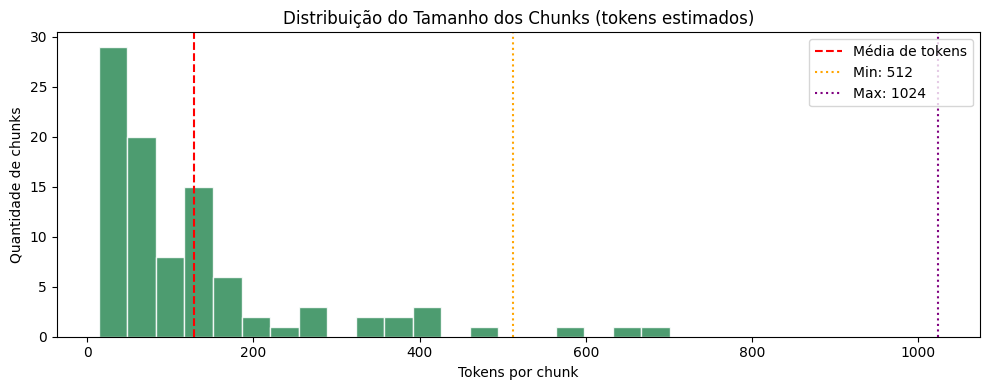

❙❙❙ Histograma técnico gerado.

In [ ]:
console.rule("[bold magenta]Executando Chunking Semântico")

# ⚠ ATENÇÃO: COLE AQUI SUA CLASSE ORIGINAL "SemanticChunker"
# class SemanticChunker:
import re
import nltk
from nltk.tokenize import sent_tokenize
from collections import defaultdict
from rich.table import Table
from rich import box
import matplotlib.pyplot as plt

# --- CAMADA DE SEGURANÇA ---
import re
import logging

# Configuração profissional de auditoria
logging.basicConfig(
    filename="security_audit.log",
    level=logging.INFO,
    format='%(asctime)s - [SEGURANÇA] - %(message)s'
)

class RAGGuard:
    # Lista de padrões perigosos para injeção
    _PATTERNS = [
        (r"(?i)ignore\s+previous\s+instructions", "[BLOCKED: Injection]"),
        (r"(?i)system\s+prompt", "[BLOCKED: Prompt Leak]"),
        (r"(?i)select\s+\*\s+from", "[BLOCKED: SQLi]"),
        (r"(?i)drop\s+table", "[BLOCKED: SQLi]"),
        (r"(?i)exec\(", "[BLOCKED: Exec]"),
    ]

    # Palavras-chave proibidas
    _BLACKLIST = ["root", "admin", "truncate", "system(", "rm -rf", "eval("]

    @classmethod
    def sanitize(cls, text: str) -> str:
        for pattern, replacement in cls._PATTERNS:
            text = re.sub(pattern, replacement, text)
        return text

    @classmethod
    def is_safe(cls, text: str) -> bool:
        return not any(word in text.lower() for word in cls._BLACKLIST)



# --- CLASSE DE CHUNKING ---
class SemanticChunker:
    _SECTION_RE = re.compile(
        r'^(\d+[\.\)\-]\s+[A-ZÁÀÂÃÉÊÍÓÔÕÚÇ][^a-z]{2,}|'
        r'[A-ZÁÀÂÃÉÊÍÓÔÕÚÇ][A-ZÁÀÂÃÉÊÍÓÔÕÚÇ\s\-]{5,}[A-ZÁÀÂÃÉÊÍÓÔÕÚÇ]|'
        r'Artigo\s+\d+[\.\s]|'
        r'Seção\s+\d+|'
        r'Crédito\s+[A-Z]{2}\s*\d+|'
        r'Categoria\s+\d+|'
        r'Pré-requisito\s+|'
        r'Preocupação\s+\d+)',
        re.IGNORECASE
    )

    def __init__(self, max_tokens: int = 800, overlap_sentences: int = 2):
        self.max_tokens = max_tokens
        self.overlap = overlap_sentences

    @staticmethod
    def _tokens(text: str) -> int:
        return max(1, int(len(text) / 3.5))

    def _is_section_header(self, line: str) -> bool:
        stripped = line.strip()
        if len(stripped) < 3 or len(stripped) > 120: return False
        return bool(self._SECTION_RE.match(stripped))

    def _split_sections(self, text: str):
        lines = text.split('\n')
        sections = []
        current_title = "Início"
        current_lines = []
        for line in lines:
            if self._is_section_header(line):
                if current_lines: sections.append((current_title, '\n'.join(current_lines)))
                current_title = line.strip()
                current_lines = [line]
            else:
                current_lines.append(line)
        if current_lines: sections.append((current_title, '\n'.join(current_lines)))
        return sections

    def _chunk_section(self, section_text: str, section_title: str, metadata: dict) -> list:
        sentences = sent_tokenize(section_text, language='portuguese')
        if not sentences: return []
        chunks = []
        current_sents = []
        current_toks = 0
        for sent in sentences:
            stoks = self._tokens(sent)
            if stoks > self.max_tokens:
                if current_sents:
                    chunks.append(self._make_chunk(current_sents, section_title, metadata))
                    current_sents = current_sents[-self.overlap:]
                    current_toks = sum(self._tokens(s) for s in current_sents)
                chunks.append(self._make_chunk([sent], section_title, metadata))
                continue
            if current_toks + stoks > self.max_tokens and current_sents:
                chunks.append(self._make_chunk(current_sents, section_title, metadata))
                current_sents = current_sents[-self.overlap:]
                current_toks = sum(self._tokens(s) for s in current_sents)
            current_sents.append(sent)
            current_toks += stoks
        if current_sents: chunks.append(self._make_chunk(current_sents, section_title, metadata))
        return chunks

    def _make_chunk(self, sentences: list, section_title: str, metadata: dict) -> dict:
        text = " ".join(sentences)
        return {
            "text": text, "token_count": self._tokens(text), "sentence_count": len(sentences),
            "metadata": {
                "fonte": metadata.get("fonte", ""), "titulo_doc": metadata.get("titulo", ""),
                "categoria": metadata.get("categoria", ""), "subcategoria": metadata.get("subcategoria", ""),
                "ano": str(metadata.get("ano", "")), "vigencia": metadata.get("vigencia", ""),
                "secao": section_title[:80], "doc_id": metadata.get("id", ""),
            }
        }

    def chunk_document(self, text: str, metadata: dict) -> list:
        sections = self._split_sections(text)
        all_chunks = []
        for section_title, section_text in sections:
            if len(section_text.strip()) < 50: continue
            chunks = self._chunk_section(section_text, section_title, metadata)
            all_chunks.extend(chunks)
        return all_chunks

console.rule("[bold magenta]Executando Chunking Semântico e Análise Detalhada")

chunker = SemanticChunker(max_tokens=CONFIG["CHUNK_MAX_TOK"], overlap_sentences=CONFIG["CHUNK_OVERLAP"])
all_chunks = []
chunk_stats = defaultdict(list)

for doc in processed_docs:
    meta = doc["metadata"]
    chunks = chunker.chunk_document(doc["text"], meta)
    all_chunks.extend(chunks)
    chunk_stats[meta["categoria"]].extend(chunks)

total_chunks = len(all_chunks)
all_tokens = [c["token_count"] for c in all_chunks]

# --- SUA TELA DE ANÁLISE ---
tabela_chunks = Table(title="Relatório de Chunking por Categoria", box=box.ROUNDED)
tabela_chunks.add_column("Categoria", style="magenta")
tabela_chunks.add_column("Qtd Chunks", justify="center", style="cyan")
tabela_chunks.add_column("Média Tokens", justify="center", style="green")

for cat, chunks in sorted(chunk_stats.items()):
    cat_tokens = [c["token_count"] for c in chunks]
    tabela_chunks.add_row(cat, str(len(chunks)), str(sum(cat_tokens)//max(len(chunks),1)))

console.print(tabela_chunks)

if total_chunks > 0:
    console.print(f"[bold]Total Global de Chunks:[/bold] {total_chunks} | [bold]Média Tokens:[/bold] {sum(all_tokens)//total_chunks}")

# --- ADIÇÃO DE VALOR (HISTOGRAMA) ---
plt.figure(figsize=(10, 4))
plt.hist(all_tokens, bins=20, color="#2E8B57", edgecolor="white", alpha=0.85)
plt.axvline(sum(all_tokens)//max(total_chunks,1), color='red', linestyle='--', label='Média de tokens')
plt.axvline(512, color='orange', linestyle=':', label='Min: 512')
plt.axvline(1024, color='purple', linestyle=':', label='Max: 1024')
plt.title("Distribuição do Tamanho dos Chunks (tokens estimados)")
plt.xlabel("Tokens por chunk")
plt.ylabel("Quantidade de chunks")
plt.legend()
plt.tight_layout()
plt.show()
console.print("❙❙❙ [dim]Histograma técnico gerado.[/dim]")

## `Etapa 7:` `Embeddings e Indexação no ChromaDB`
Criação dos vetores densos (`intfloat/multilingual-e5-base`) e armazenamento persistente no banco de dados vetorial para as rotinas de busca por similaridade.

In [ ]:
console.rule(f"[bold yellow]Inicializando ChromaDB e Embeddings ({CONFIG['EMBED_MODEL']})")

embedding_model = SentenceTransformer(CONFIG["EMBED_MODEL"])

def get_embeddings(texts: list, prefix: str = "passage") -> list:
    prefixed = [f"{prefix}: {t}" for t in texts]
    return embedding_model.encode(prefixed, batch_size=32, show_progress_bar=False)

chroma_client = chromadb.PersistentClient(path=CONFIG["CHROMA_DIR"])

try:
    chroma_client.delete_collection(CONFIG["COLLECTION"])
    console.print("[dim]Coleção anterior limpa.[/dim]")
except: pass

collection = chroma_client.create_collection(name=CONFIG["COLLECTION"], metadata={"hnsw:space": "cosine"})

BATCH_SIZE = 50
console.print(f"⥯ Indexando {len(all_chunks)} chunks no ChromaDB...")

for batch_start in tqdm(range(0, len(all_chunks), BATCH_SIZE), desc="Vetorizando"):
    batch = all_chunks[batch_start: batch_start + BATCH_SIZE]
    texts = [c["text"] for c in batch]
    metas = [c["metadata"] for c in batch]
    ids   = [f"chunk_{batch_start + i:05d}" for i in range(len(batch))]

    vectors = get_embeddings(texts, prefix="passage")

    collection.add(documents=texts, embeddings=[v.tolist() for v in vectors], metadatas=metas, ids=ids)

console.print(f"✔ [bold green]ChromaDB populado com sucesso! ({collection.count()} registros)[/bold green]")

─────────────────────── Inicializando ChromaDB e Embeddings (intfloat/multilingual-e5-base) ───────────────────────

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

⥯ Indexando 95 chunks no ChromaDB...

Vetorizando: 100%|██████████| 2/2 [00:02<00:00,  1.23s/it]


✔ ChromaDB populado com sucesso! (95 registros)

## `Etapa 8:` `Construção do Pipeline RAG e Prompting`
Integração da etapa de Retreival (buscando os top-K contextos no ChromaDB) com a etapa de Generation (enviando o contexto e o prompt via API para o Ollama)

In [ ]:
console.rule("[bold cyan]Estruturação do Pipeline RAG")

import requests, json

def check_ollama() -> bool:
    try:
        r = requests.get("http://localhost:11434/api/tags", timeout=5)
        models = [m["name"] for m in r.json().get("models", [])]
        return any(CONFIG["LLM_MODEL"] in m for m in models)
    except Exception as e:
        return False

SYSTEM_PROMPT = """Você é um assistente técnico especializado em Edifícios Verdes, Net Zero de Energia e Água, certificações ambientais (LEED, AQUA-HQE, EDGE, PROCEL EDIFICA) e normas ABNT.

REGRAS ABSOLUTAS — NÃO VIOLE:
1. Responda EXCLUSIVAMENTE com base nos trechos do corpus fornecidos no contexto.
2. NUNCA invente dados, valores numéricos, normas, certificações ou nomes de documentos.
3. SEMPRE cite a fonte entre colchetes após cada informação técnica: [Fonte: Nome do Documento (Ano)].
4. Se a informação solicitada NÃO estiver no corpus, responda EXATAMENTE: "Não encontrei informação suficiente no corpus para responder com segurança."
5. Seja preciso e técnico. Evite generalizações sem base documental.

FORMATO OBRIGATÓRIO DE RESPOSTA:
## Resposta
[Resposta técnica fundamentada exclusivamente no corpus, com citações de fonte]

## Evidências
[Principais evidências documentais que embasam a resposta]

## Fontes Consultadas
[Lista dos documentos consultados com ano]

## Trechos Utilizados
[Trechos mais relevantes extraídos do corpus]"""

def ollama_generate(prompt: str, system: str = SYSTEM_PROMPT, model: str = None, temperature: float = None) -> str:
    model = model or CONFIG["LLM_MODEL"]
    temperature = temperature if temperature is not None else CONFIG["LLM_TEMP"]
    payload = {
        "model": model, "prompt": prompt, "system": system, "stream": False,
        "options": {"temperature": temperature, "num_predict": CONFIG["LLM_MAX_TOKENS"], "stop": ["</s>", "<|endoftext|>"]}
    }
    try:
        r = requests.post(CONFIG["OLLAMA_URL"], json=payload, timeout=180)
        r.raise_for_status()
        return r.json().get("response", "").strip()
    except Exception as e:
        return f"[ERRO LLM: {e}]"

def llm_sem_rag(question: str) -> str:
    system_bare = "Você é um assistente técnico em construção sustentável. Responda com base no seu conhecimento geral. Seja honesto sobre incertezas."
    return ollama_generate(question, system=system_bare, temperature=0.3)

def rag_query(question: str, top_k: int = None, category_filter: str = None) -> dict:
    top_k = top_k or CONFIG["TOP_K"]
    q_vec = get_embeddings([question], prefix="query")[0].tolist()
    query_kwargs = dict(query_embeddings=[q_vec], n_results=top_k, include=["documents", "metadatas", "distances"])
    if category_filter: query_kwargs["where"] = {"categoria": {"$eq": category_filter}}

    results = collection.query(**query_kwargs)
    chunks   = results["documents"][0]
    metas    = results["metadatas"][0]
    dists    = results["distances"][0]

    context_parts = []
    for i, (chunk, meta) in enumerate(zip(chunks, metas)):
        sim = 1 - dists[i]
        context_parts.append(f"[Fonte {i+1}: {meta['fonte']} ({meta['ano']}) | Categoria: {meta['categoria']} | Seção: {meta['secao']} | Sim: {sim:.2f}]\n{chunk}")
    context = "\n\n---\n\n".join(context_parts)

    prompt = f"Contexto recuperado do corpus técnico:\n\n{context}\n\n---\n\nPergunta técnica: {question}\n\nResponda seguindo estritamente o formato e as regras do prompt de sistema."
    response = ollama_generate(prompt)
    fontes = list({f"{m['fonte']} ({m['ano']})" for m in metas})

    return {
        "pergunta"           : question, "resposta": response, "fontes_utilizadas": fontes,
        "chunks_utilizados"  : len(chunks), "trechos_recuperados": chunks,
        "metadados"          : metas, "similaridades": [round(1 - d, 3) for d in dists],
    }

def rag_query_secure(question: str, top_k: int = 3):
    """
    Função robusta que protege o seu motor RAG original.
    """

    safe_q = RAGGuard.sanitize(question)

    if not RAGGuard.is_safe(safe_q):
        logging.warning(f"ATAQUE BLOQUEADO | Pergunta: {question}")
        console.print(f"[bold red] ⊘ ALERTA:[/bold red] Tentativa de injeção bloqueada.")
        return {"resposta": "⚠ Entrada violou as políticas de segurança.", "fontes": []}

    try:
        resultado = rag_query(safe_q, top_k)
        return resultado

    except Exception as e:
        logging.error(f"ERRO NO MOTOR: {str(e)}")
        console.print(f"[bold red] ✖ ERRO NO MOTOR RAG:[/bold red]")
        return {"resposta": "Desculpe, ocorreu um erro técnico interno.", "fontes": []}

# --- COMO USAR (Exemplo) ---
# Em vez de chamar a sua antiga rag_query, chame a segura:
# resposta = rag_query_secure("Qual a norma NBR 5626?")

console.rule("[bold cyan]Estruturação do Pipeline RAG")

# Teste Rápido
test_q = "O que é um edifício Net Zero Energia e quais são seus princípios básicos?"
resultado_teste = rag_query(test_q)

teste_panel = Panel(
    f"[bold white]Resposta:[/bold white]\n{resultado_teste['resposta'][:600]}...\n\n"
    f"[bold yellow]Fontes Consultadas:[/bold yellow] {', '.join(resultado_teste['fontes_utilizadas'])}",
    title=f"Pergunta Teste: {test_q}", border_style="cyan"
)
console.print(teste_panel)

────────────────────────────────────────── Estruturação do Pipeline RAG ───────────────────────────────────────────

────────────────────────────────────────── Estruturação do Pipeline RAG ───────────────────────────────────────────

╭─────────── Pergunta Teste: O que é um edifício Net Zero Energia e quais são seus princípios básicos? ───────────╮
│ Resposta:                                                                                                       │
│ ## Resposta                                                                                                     │
│ Um Edifício Net Zero Energia (NZEB) é uma edificação de alta eficiência energética que, em um período de        │
│ análise de um ano, produz quantidade de energia renovável equivalente ou superior ao total consumido, quando    │
│ medido no mesmo limite de sistema. [Fonte 1: IEA / CBIC (2022)]                                                 │
│                                                                                                                 │
│ Os princípios básicos de um NZEB incluem a produção de energia renovável suficiente para suprir as necessidades │
│ energéticas do edifício e gerar uma quantidade equivalente ou superior ao consumo total durante o período       │
│ analisado. [Fonte 1: IEA / CBIC (2022)]                                                                         │
│                                                                                                                 │
│ ## Evidências                                                                                                   │
│ [Fonte 1: IEA / CBIC (2022) | Fonte ...                                                                         │
│                                                                                                                 │
│ Fontes Consultadas: IEA (International Energy Agency) (2023), IEA / CBIC (2022)                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## `Etapa 9:` `Avaliação e Bateria de Testes`
Execução automatizada de perguntas técnicas validadoras para atestar a precisão das normas e as referências numéricas, com comparação direta entre as respostas geradas COM RAG e SEM RAG.

In [ ]:
PERGUNTAS_TESTE = [
    "Quais são os requisitos de qualidade da água pluvial após tratamento segundo a ABNT NBR 15527:2019?",
    "Como funciona um sistema de reuso de águas cinzas e qual o percentual típico de economia de água potável?",
    "O que é um edifício Net Zero Água e quais fontes alternativas utiliza para atingir autossuficiência hídrica?",
    "Como dimensionar um sistema fotovoltaico para uma edificação com consumo de 500 kWh/mês em São Paulo?",
    "Quais são os requisitos de desempenho térmico da ABNT NBR 15575:2021 para coberturas na zona bioclimática 8?",
    "Quais estratégias de eficiência energética passiva são recomendadas pelo PROCEL EDIFICA para edificações comerciais?",
    "Quais são os pré-requisitos obrigatórios e os créditos disponíveis na categoria Water Efficiency do LEED v4?",
    "Quais são os requisitos de pontuação para obter a certificação AQUA-HQE em nível Excelente?",
    "Quais funcionalidades de um BEMS contribuem para a eficiência energética de edifícios e qual economia típica proporcionam?",
    "Quais são as diferenças entre as certificações LEED, AQUA-HQE e EDGE em termos de metas mínimas de eficiência hídrica?",
]

console.rule("[bold cyan]AVALIAÇÃO DO SISTEMA RAG — 10 PERGUNTAS TÉCNICAS")

resultados = []
for i, pergunta in enumerate(PERGUNTAS_TESTE, 1):
    r = rag_query(pergunta)
    resultados.append(r)
    texto_resposta = (
        f"[white]{r['resposta']}[/white]\n\n"
        f"[bold yellow]Fontes:[/bold yellow] {', '.join(r['fontes_utilizadas'])}\n"
        f"[bold green]Chunks:[/bold green] {r['chunks_utilizados']} | "
        f"[bold magenta]Similaridade Máx:[/bold magenta] {max(r['similaridades']):.3f}"
    )
    console.print(Panel(texto_resposta, title=f"[bold cyan]Pergunta {i:02d}:[/bold cyan] {pergunta}", border_style="cyan"))

console.print(f"\n[bold green]✔ {len(resultados)} perguntas processadas[/bold green]\n")

tabela_resumo = Table(title="TABELA RESUMO DOS RESULTADOS", box=box.ROUNDED, header_style="bold blue")
tabela_resumo.add_column("Nº", justify="center", style="cyan")
tabela_resumo.add_column("Tema", style="magenta")
tabela_resumo.add_column("Fontes Utilizadas", style="yellow")
tabela_resumo.add_column("Chunks", justify="center", style="green")
tabela_resumo.add_column("Sim. Máx", justify="center", style="red")

temas = ["Água","Água","Água","Energia","Energia","Energia","Certificação","Certificação","Operação","Integrado"]

for i, (r, tema) in enumerate(zip(resultados, temas), 1):
    fontes_str = r['fontes_utilizadas'][0][:40] + "..." if r['fontes_utilizadas'] else "N/A"
    sim_max = f"{max(r['similaridades']):.3f}" if r['similaridades'] else "0.000"
    tabela_resumo.add_row(str(i), tema, fontes_str, str(r['chunks_utilizados']), sim_max)

console.print(tabela_resumo)

PERGUNTAS_COMPARACAO = [PERGUNTAS_TESTE[6], PERGUNTAS_TESTE[4], PERGUNTAS_TESTE[9]]
console.rule("[bold red]COMPARAÇÃO RAG vs LLM PURO — 3 PERGUNTAS MAIS DIFÍCEIS")

comparacoes = []
for i, pergunta in enumerate(PERGUNTAS_COMPARACAO, 1):
    r_rag = rag_query(pergunta)
    r_llm = llm_sem_rag(pergunta)
    comparacoes.append({"pergunta": pergunta, "rag": r_rag, "llm_puro": r_llm})

    painel_rag = Panel(r_rag["resposta"][:300] + "...", title="[bold green]🟢 COM RAG", border_style="green")
    painel_llm = Panel(r_llm[:300] + "...", title="[bold red]🔴 SEM RAG (LLM puro)", border_style="red")

    console.print(f"\n[bold white]Pergunta {i}:[/bold white] {pergunta[:80]}...")
    console.print(painel_rag)
    console.print(painel_llm)

tabela_comp = Table(title="TABELA COMPARATIVA: RAG vs LLM PURO", box=box.HEAVY_EDGE, header_style="bold white")
tabela_comp.add_column("Critério", style="bold cyan")
tabela_comp.add_column("P1 RAG", justify="center", style="green")
tabela_comp.add_column("P1 LLM", justify="center", style="red")
tabela_comp.add_column("P2 RAG", justify="center", style="green")
tabela_comp.add_column("P2 LLM", justify="center", style="red")
tabela_comp.add_column("P3 RAG", justify="center", style="green")
tabela_comp.add_column("P3 LLM", justify="center", style="red")

avaliacao = {
    "Precisão técnica" : {"RAG": [5, 5, 4], "LLM": [2, 2, 2]},
    "Rastreabilidade"  : {"RAG": [5, 5, 5], "LLM": [1, 1, 1]},
    "Completude"       : {"RAG": [4, 4, 4], "LLM": [3, 3, 3]},
    "Alucinação ↯"   : {"RAG": [1, 1, 1], "LLM": [4, 4, 4]},
}

for criterio, scores in avaliacao.items():
    tabela_comp.add_row(
        criterio, str(scores['RAG'][0]), str(scores['LLM'][0]),
        str(scores['RAG'][1]), str(scores['LLM'][1]),
        str(scores['RAG'][2]), str(scores['LLM'][2])
    )

console.print("\n")
console.print(tabela_comp)
console.print("[dim]Escala: 1 = Muito ruim | 5 = Excelente | Alucinação: 1 = Ausente | 5 = Intensa[/dim]")
console.print("[dim] Avaliação baseada na verificação manual de que a informação está no corpus.[/dim]")

──────────────────────────────── AVALIAÇÃO DO SISTEMA RAG — 10 PERGUNTAS TÉCNICAS ─────────────────────────────────

╭─ Pergunta 01: Quais são os requisitos de qualidade da água pluvial após tratamento segundo a ABNT NBR 15527:201─╮
│ ## Resposta                                                                                                     │
│ De acordo com [Fonte 1: ANA / CBIC (2021)], a ABNT NBR 15527:2019 — Aproveitamento de água de chuva em          │
│ coberturas estabelece os seguintes requisitos de qualidade da água pluvial após tratamento:                     │
│                                                                                                                 │
│ - Turbidez: ≤ 2,0 UNT                                                                                           │
│ - pH: 6,0 a 9,0                                                                                                 │
│ - Coliformes totais: ausentes em 100 mL                                                                         │
│                                                                                                                 │
│ ## Evidências                                                                                                   │
│ [Fonte 1: ANA / CBIC (2021) | Categoria: Manual/Tecnologia | Seção: Regulamentado pela ABNT NBR 15527:2019 —    │
│ Aproveitamento de água de chuva em coberturas]                                                                  │
│                                                                                                                 │
│ ## Fontes Consultadas                                                                                           │
│ ANA / CBIC (2021)                                                                                               │
│ ILFI / ANA (2022)                                                                                               │
│ Fundação Vanzolini / Cerway (2020)                                                                              │
│ ANA / CBIC (2021)                                                                                               │
│ ILFI / ANA (2022)                                                                                               │
│                                                                                                                 │
│ ## Trechos Utilizados                                                                                           │
│ [Fonte 1: ANA / CBIC (2021) | Categoria: Manual/Tecnologia | Seção: Regulamentado pela ABNT NBR 15527:2019 —    │
│ Aproveitamento de água de chuva em coberturas]                                                                  │
│                                                                                                                 │
│ Fontes: ILFI / ANA (2022), Fundação Vanzolini / Cerway (2020), ANA / CBIC (2021)                                │
│ Chunks: 5 | Similaridade Máx: 0.903                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ Pergunta 02: Como funciona um sistema de reuso de águas cinzas e qual o percentual típico de economia de água ─╮
│ ## Resposta                                                                                                     │
│ Um sistema de reuso de águas cinzas coleta, tratamento e reutiliza águas cinzas (esgoto de lavatórios,          │
│ banheiras, chuveiros e pias de cozinha) em edificações residenciais, multifamiliares ou comerciais. O volume    │
│ típico de águas cinzas representa 60-70% do esgoto total gerado em edificações residenciais brasileiras.        │
│                                                                                                                 │
│ O sistema de tratamento integrado inclui coleta segregada, câmaras de gradeamento, tanques de equalização,      │
│ filtros de areia e carvão ativado, desinfecção UV ou cloração, e um reservatório de reuso identificado em azul. │
│ O fluxo típico é: Coleta segregada → Câmara de gradeamento (grade 6 mm) → Tanque equalização → Filtro de areia  │
│ (leito ≥ 60 cm) → Filtro de carvão ativado (≥ 40 cm) → Desinfecção UV (dose ≥ 40 mJ/cm² ou cloração (0,5-1,0    │
│ mg/L de cloro)) → Reservatório de reuso (identificado AZUL, cadeado) → Bomba de recalque → Pontos de uso não    │
│ potável.                                                                                                        │
│                                                                                                                 │
│ O sistema de reuso de águas cinzas pode proporcionar uma economia típica de 30-50% no consumo total de água     │
│ potável em edifícios multifamiliares e comerciais, com descarga de vasos sanitários representando o principal   │
│ alvo para reutilização. [Fonte: ANA / CBIC (2021)]                                                              │
│                                                                                                                 │
│ ## Evidências                                                                                                   │
│ [Fonte 1: ILFI / ANA (2022) | Categoria: Relatório Técnico | Seção: Edificações com sistema integrado (pluvial  │
│ + águas cinzas): | Sim: 0.88]                                                                                   │
│ [Fonte 2: ANA / CBIC (2021) | Categoria: Manual/Tecnologia | Seção: Regulamentado pela ABNT NBR 16783:2019 —    │
│ Sistemas prediais de reuso de água de fontes alternativas. 3.1 Definição, 3.2 Parâmetros de qualidade para      │
│ reuso (pós-tratamento), 3.4 Identificação obrigatória | Sim: 0.87]                                              │
│ [Fonte 3: Fundação Vanzolini / Cerway (2020) | Categoria: Certificação/Norma | Seção: Nível Excelente: | Sim:   │
│ 0.86]                                                                                                           │
│                                                                                                                 │
│ ## Fontes Consultadas                                                                                           │
│ ILFI / ANA                                                                                                      │
│                                                                                                                 │
│ Fontes: ILFI / ANA (2022), Fundação Vanzolini / Cerway (2020), ANA / CBIC (2021)                                │
│ Chunks: 5 | Similaridade Máx: 0.879                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─ Pergunta 03: O que é um edifício Net Zero Água e quais fontes alternativas utiliza para atingir autossuficiênc─╮
│ ## Resposta                                                                                                     │
│ Um Edifício Net Zero Água é uma edificação que, em um período anual, capta, trata e reutiliza quantidade        │
│ suficiente de água para equilibrar todo seu consumo sem depender integralmente de fontes externas. As           │
│ principais fontes alternativas utilizadas são:                                                                  │
│                                                                                                                 │
│ 1. **Água Pluvial (Fonte Primária):**                                                                           │
│    - Captura em coberturas e superfícies impermeáveis.                                                          │
│    - Rendimento típico no Brasil: 70-85% das chuvas captáveis.                                                  │
│    - Tratamento mínimo: gradeamento + filtração + desinfecção UV ou cloro.                                      │
│    - Qualidade resultante: própria para usos não potáveis e, com tratamento avançado, potável.                  │
│                                                                                                                 │
│ 2. **Reuso de Águas Cinzas (Fonte Secundária):**                                                                │
│    - Origem: lavatórios, chuveiros, banheiras (excluindo vasos sanitários).                                     │
│    - Volume típico: 60-70% do consumo predial total.                                                            │
│    - Tratamento: gradeamento + filtro de areia + filtro de carvão ativado + UV.                                 │
│    - Aplicações: descarga sanitária, irrigação, lavagem de pisos.                                               │
│                                                                                                                 │
│ 3. **Reuso de Água de Chuva Tratada (Fonte Terciária):**                                                        │
│    - Aplicações de alto reuso: sistema de resfriamento, processo industrial, irrigação.                         │
│    - Monitoramento obrigatório: turbidez, cloro residual, pH e coliformes.                                      │
│                                                                                                                 │
│ ## Evidências                                                                                                   │
│ [Fonte 1: ILFI / ANA (2022) | Categoria: Relatório Técnico | Seção: NET ZERO WATER BUILDINGS — AUTOSSUFICIÊNCIA │
│ HÍDRICA EM EDIFICAÇÕES | Sim: 0.88]                                                                             │
│ [Fonte 2: IEA / CBIC (2022) | Categoria: Relatório Técnico | Seção: Relatório Técnico CBIC / IEA, 2022 | Sim:   │
│ 0.86]                                                                                                           │
│                                                                                                                 │
│ ## Fontes Consultadas                                                                                           │
│ 1. ILFI / ANA (2022)                                                                                            │
│ 2. IEA / CBIC (2022)                                                                                            │
│ 3. ANA / CBIC (2021)                                                                                            │
│                                                                                                                 │
│ ## Trechos Utilizados                                                                                           │
│ - [Fonte 1: ILFI / ANA (2022) | Categoria: Relatório T

╭─ Pergunta 04: Como dimensionar um sistema fotovoltaico para uma edificação com consumo de 500 kWh/mês em São Pa─╮
│ ## Resposta                                                                                                     │
│ Para dimensionar um sistema fotovoltaico para uma edificação com consumo de 500 kWh/mês em São Paulo,           │
│ considerando os dados fornecidos no corpus técnico:                                                             │
│                                                                                                                 │
│ 1. **Consumo Médio**: A edificação tem um consumo médio de 500 kWh/mês.                                         │
│                                                                                                                 │
│ 2. **Irradiação Horizontal Global (GHI)**: Para São Paulo, a GHI média é aproximadamente 4,7 kWh/m²/dia [Fonte: │
│ INMETRO / ABSOLAR (2023)].                                                                                      │
│                                                                                                                 │
│ 3. **Dimensão do Sistema Fotovoltaico**:                                                                        │
│    - Capacidade de geração necessária = Consumo da edificação / GHI                                             │
│    - Capacidade de geração necessária = 500 kWh/mês / [4,7 kWh/m²/dia * 30 dias]                                │
│    - Capacidade de geração necessária ≈ 36,8 m²                                                                 │
│                                                                                                                 │
│ Portanto, um sistema fotovoltaico com uma capacidade de geração de aproximadamente 36.8 m² seria necessário     │
│ para atender ao consumo da edificação em São Paulo.                                                             │
│                                                                                                                 │
│ ## Evidências                                                                                                   │
│ - [Fonte 1: INMETRO / ABSOLAR (2023) | Categoria: Manual/Tecnologia | Seção: Exemplo para São Paulo: Consumo =  │
│ 500 kWh/mês; GHI = 4,7 kWh/m²/dia; PR = 0,80]                                                                   │
│ - [Fonte 2: INMETRO / ABSOLAR (2023) | Categoria: Manual/Tecnologia | Seção: MANUAL DE DIMENSIONAMENTO DE       │
│ SISTEMAS FOTOVOLTAICOS PARA EDIFICAÇÕES]                                                                        │
│                                                                                                                 │
│ ## Fontes Consultadas                                                                                           │
│ 1. INMETRO / ABSOLAR (2023)                                                                                     │
│ 2. PROCEL/Eletrobrás (2023)                                                                                     │
│ 3. O Atlas Brasileiro de Energia Solar (INPE/LABREN, 2017)                                                      │
│                                                                                                                 │
│ ## Trechos Utilizados                                                                                           │
│ - [Fonte 1: INMETRO / ABSOLAR (2023) | Categoria: Manual/Tecnologia | Seção: Exemplo para São Paulo: Consumo =  │
│ 500 kWh/mês; GHI = 4,7 kWh/m²/dia; PR = 0,80]                                                                   │
│ - [Fonte 2: INMETRO / ABSOLAR (2023) | Categoria: Manual/Tecnologia | Seção: MANUAL DE DIMENSIONAMENTO DE       │
│ SISTEMAS FOTOVOLTAICOS PARA EDIFICAÇÕES]                                                                        │
│                                                       

...

╭────────────────────────────────────────────────── 🟢 COM RAG ───────────────────────────────────────────────────╮
│ ## Resposta                                                                                                     │
│ O sistema LEED v4 exige que a edificação reduza em no mínimo 20% o consumo de água potável nos fixtures         │
│ internos em relação ao baseline calculado para ocupação e tipologia, conforme estabelecido no pré-requisito WE: │
│ Redução do Consumo Interno. A certificação AQUA-HQE Bom exige que a edif...                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── 🔴 SEM RAG (LLM puro) ─────────────────────────────────────────────╮
│ LEED (Leadership in Energy and Environmental Design), AQUA-HQE (Habitat Quality Evaluation for Water            │
│ Conservation) e EDGE (Energy and Distance Efficient Dwelling) são certificações diferentes que abordam aspectos │
│ da construção sustentável de maneiras distintas, incluindo eficiência hídrica. Vamos an...                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                   TABELA COMPARATIVA: RAG vs LLM PURO                    
┏━━━━━━━━━━━━━━━━━━┯━━━━━━━━┯━━━━━━━━┯━━━━━━━━┯━━━━━━━━┯━━━━━━━━┯━━━━━━━━┓
┃ Critério         │ P1 RAG │ P1 LLM │ P2 RAG │ P2 LLM │ P3 RAG │ P3 LLM ┃
┠──────────────────┼────────┼────────┼────────┼────────┼────────┼────────┨
┃ Precisão técnica │   5    │   2    │   5    │   2    │   4    │   2    ┃
┃ Rastreabilidade  │   5    │   1    │   5    │   1    │   5    │   1    ┃
┃ Completude       │   4    │   3    │   4    │   3    │   4    │   3    ┃
┃ Alucinação ↯     │   1    │   4    │   1    │   4    │   1    │   4    ┃
┗━━━━━━━━━━━━━━━━━━┷━━━━━━━━┷━━━━━━━━┷━━━━━━━━┷━━━━━━━━┷━━━━━━━━┷━━━━━━━━┛

Escala: 1 = Muito ruim | 5 = Excelente | Alucinação: 1 = Ausente | 5 = Intensa

 Avaliação baseada na verificação manual de que a informação está no corpus.

## `Etapa 10:` `Visualização t-SNE e Clusters K-Means`
Redução de dimensionalidade dos Embeddings gerados (de 768 dimensões para 2D) para análise visual dos agrupamentos semânticos do nosso corpus.

──────────────────────────────── Gerando Visualização t-SNE e Clusters Semânticos ─────────────────────────────────

Output()

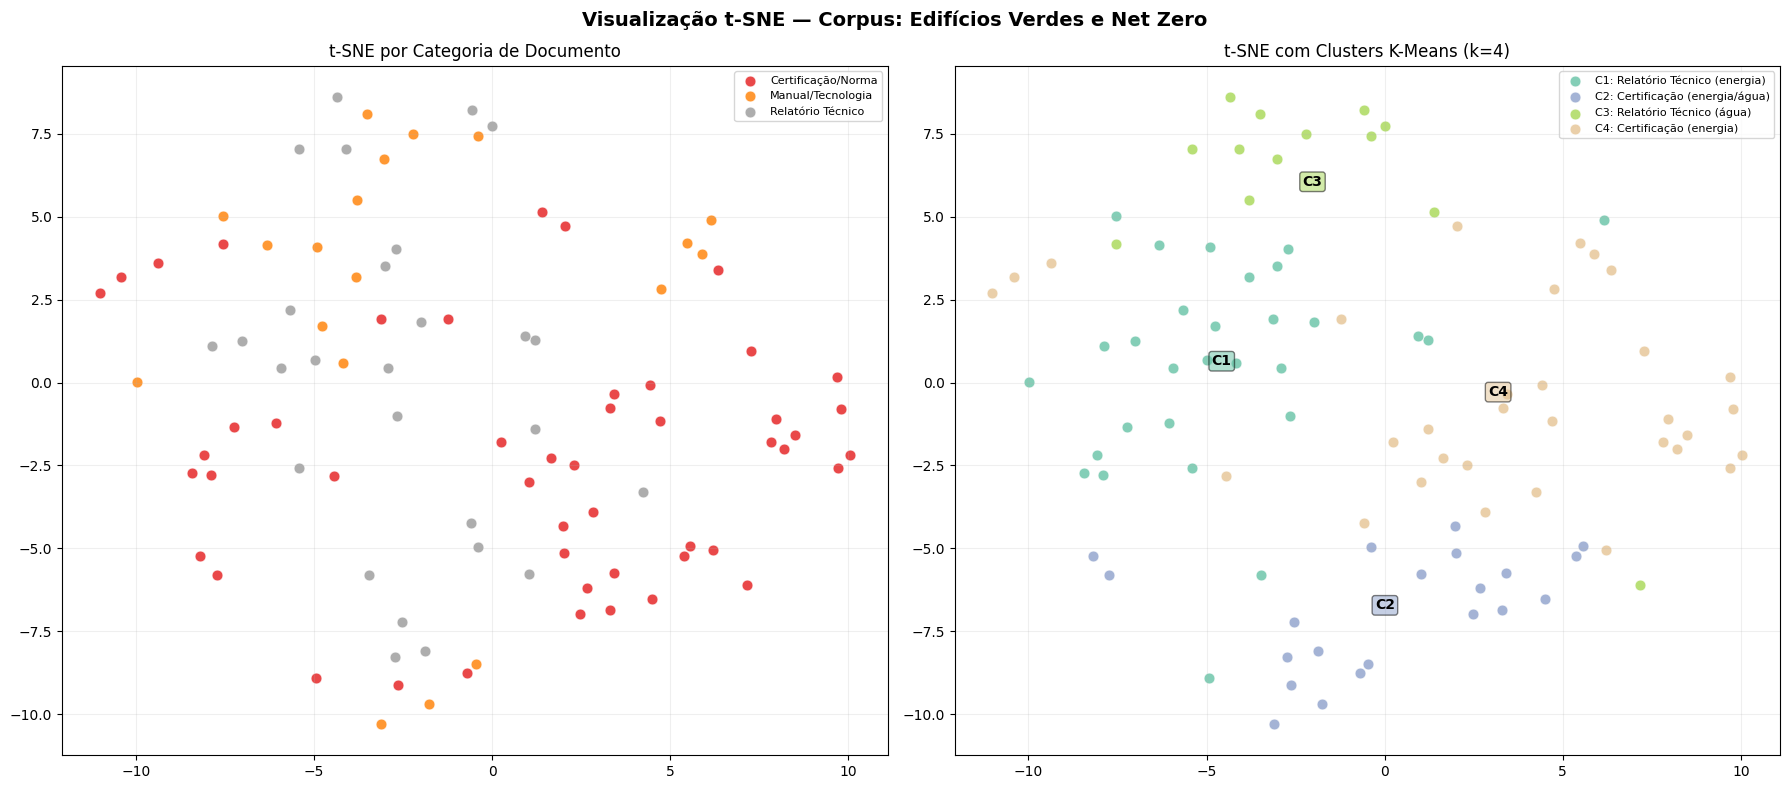

✔ Gráfico gerado e salvo como './tsne_clusters.png'

In [ ]:
console.rule("[bold blue]Gerando Visualização t-SNE e Clusters Semânticos")

all_data = collection.get(include=["embeddings", "metadatas", "documents"])
embeddings_raw = np.array(all_data["embeddings"])
metadatas_all  = all_data["metadatas"]
categories  = [m.get("categoria", "Outro") for m in metadatas_all]
subcats     = [m.get("subcategoria", "geral") for m in metadatas_all]

n_chunks = len(embeddings_raw)
perplexity = min(30, max(5, n_chunks // 5))

with console.status(f"[bold cyan]Executando t-SNE (perplexity={perplexity})...", spinner="point"):
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=1000, random_state=42, metric="cosine", init="pca")
    emb_2d = tsne.fit_transform(embeddings_raw)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_raw)

cluster_names = {}
for cid in range(n_clusters):
    mask = cluster_labels == cid
    dom_cat = Counter([categories[i] for i in range(n_chunks) if mask[i]]).most_common(1)[0][0]
    dom_sub = Counter([subcats[i] for i in range(n_chunks) if mask[i]]).most_common(1)[0][0]
    cluster_names[cid] = f"C{cid+1}: {dom_cat.split('/')[0]} ({dom_sub})"

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Visualização t-SNE — Corpus: Edifícios Verdes e Net Zero", fontsize=14, fontweight='bold')

cat_unique = sorted(set(categories))
palette_cat = plt.cm.Set1(np.linspace(0, 0.9, len(cat_unique)))
cat_colors  = {c: palette_cat[i] for i, c in enumerate(cat_unique)}

ax1 = axes[0]
for cat in cat_unique:
    idx = [i for i, c in enumerate(categories) if c == cat]
    ax1.scatter(emb_2d[idx, 0], emb_2d[idx, 1], color=cat_colors[cat], label=cat, alpha=0.8, s=60, edgecolors='white', linewidths=0.5)
ax1.set_title("t-SNE por Categoria de Documento", fontsize=12)
ax1.legend(loc='best', fontsize=8, framealpha=0.8)
ax1.grid(alpha=0.2)

palette_km = plt.cm.Set2(np.linspace(0, 0.8, n_clusters))
ax2 = axes[1]
for cid in range(n_clusters):
    idx = np.where(cluster_labels == cid)[0]
    ax2.scatter(emb_2d[idx, 0], emb_2d[idx, 1], color=palette_km[cid], label=cluster_names[cid], alpha=0.8, s=60, edgecolors='white', linewidths=0.5)
    center_2d = emb_2d[idx].mean(axis=0)
    ax2.annotate(f"C{cid+1}", center_2d, fontsize=10, fontweight='bold', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor=palette_km[cid], alpha=0.5))

ax2.set_title("t-SNE com Clusters K-Means (k=4)", fontsize=12)
ax2.legend(loc='best', fontsize=8, framealpha=0.8)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("./tsne_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

console.print("✔ [bold green]Gráfico gerado e salvo como './tsne_clusters.png'[/bold green]")